In [1]:
def import_packages():
    '''
        Imports packages necessary for scientific computation
        
        Returns: A tuple containing these following modules.
                 1.Numpy(np)
                 2.matplotlib.pyplot(plt)
                 3.scipy.integrate.odeint(odeint)
                 4.math
    '''
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.integrate import odeint
    import math
    return np, plt, odeint, math

In [2]:
np, plt, odeint, math = import_packages() #Importing all necessary Packages  

# Problem 1: Gillespie’s Direct Algorithm and Stochastic Hallmarks

### Stochastic Model Functions

In [5]:
def process_probabilities(state, params):
    '''
        Calculates the Propensity Functions for the SIR Model 
        
        Parameters :
        
        state (dict): A dictionary containing the current counts of each compartment:
            - 'X' (int) : Number of susceptible individuals
            - 'Y' (int) : Number of infected individuals
            - 'Z' (int) : Number of recovered individuals
        params (dict): A dictionary containing the model parameters:
            - 'beta' (float) : Transmission rate
            - 'gamma' (float) : Recovery rate
            - 'mu' (float) : Birth and natural death rate

        Returns :
        a(np.ndarray): An array consisting of Propensity Functions, wherein 
        a[0] : Transmission Propensity 
        a[1] : Recovery Propensity 
        a[2] : Birth Propensity 
        a[3] : Death Propensity from Susceptible Population (X)
        a[4] : Death Propensity from Infected Popultion (Y)
        a[5] : Death Propensity from Recovered Population (Z)
        
    '''
    # Initialize variables
    X, Y, Z = state['X'], state['Y'], state['Z']
    a = np.zeros(6)
    N = X + Y + Z

    # Calculate the rates
    a[0] = (params['beta'] * X * Y) / N # Transmission rate
    a[1] = params['gamma'] * Y # Recovery Rates
    a[2] = params['mu'] * N # Birth
    a[3] = params['mu'] * X # Death from X
    a[4] = params['mu'] * Y # Death from Y
    a[5] = params['mu'] * Z # Death from Z
    
    return a

In [6]:
def SIR_stochastic(params, initial_values, end_time):
    '''
     Simulate the SIR epidemic model using a stochastic approach.
    
        Parameters :
        
            params (dict) : A dictionary containing the model parameters:
                - 'beta' (float) : The transmission rate of the disease
                - 'gamma' (float) : The recovery rate of the infected individuals
                - 'mu' (float) : The birth and natural death rate of the population
        
            initial_values (dict) : A dictionary containing the initial state of the system:
                - 'X' (int) : Initial number of susceptible individuals
                - 'Y' (int) : Initial number of infected individuals
                - 'Z' (int) : Initial number of recovered individuals
        
            end_time (float) : The time until which the simulation will run.

        Returns:
            dict: A dictionary containing the results of the simulation:
                - 'time' (list) : List of time points when events occurred.
                - 'X' (list) : List of the number of susceptible individuals at each point in time.
                - 'Y' (list): List of the number of infected individuals at each point in time.
                - 'Z' (list): List of the number of recovered individuals at each point in time.
                - 'extinction' (boolean): Specifies whether the simulation ended in an extinction or not.
                - 'extinction_time' (float): The time point when the disease got extinct. 
    '''
  
    state = initial_values.copy() # Copying and storing the initial population of susceptible, infected and recovered individuals 
    time = 0
    result = {'time': [], 'X': [], 'Y': [], 'Z': [], 'extinction': False, 'extinction_time': float('inf')}

    # Run the algorithm until we get to the time wanted or until there is an extinction of the disease
    while time < end_time and state['Y'] > 0:        
        # Get the rates
        probs = process_probabilities(state, params)

        # Get the time until the next event
        tau = (- 1 / sum(probs)) * np.log(np.random.random())
        time += tau

        # Get the type of the event
        which = process(probs)

        # Update the state
        new_state = update_state(state, which)

        # Append the time and new state to the previous results
        result['time'].append(time)
        result['X'].append(new_state['X'])
        result['Y'].append(new_state['Y'])
        result['Z'].append(new_state['Z'])    

    if state['Y'] < 1:
        result['extinction'] = True
        result['extinction_time'] = time
        
    return result

In [7]:
def process(probs):
    '''
    Function selects next event based on propensities and identifies which event should occur based on the cumulative probability distribution 
    
    Parameters :
        probs (numpy.ndarray or list) : A list or array of propensity functions (rates) for each possible event

    Returns :
        int : The index of the event that occurs
    '''
    # Initialize variables
    which = 0
    cumulative_sum = probs[0]

    # Calculate r2
    r2 = np.random.random() * sum(probs)

    # Find which event occured
    while r2 > cumulative_sum:
        which += 1
        cumulative_sum += probs[which]
        
    return which + 1

In [8]:
def update_state(state, which):
    '''
    Updates the state of the population based on the event that occur 
        
        Parameters:
            state (dict) : The current state of the population
            which (int) : The event index 
        
        Returns:
            dict : The updated state of the population with modified values for 'X', 'Y', and 'Z'.
    '''
    if which == 1: # Infection
        state['X'] -= 1
        state['Y'] += 1
    elif which == 2: # Recovery
        state['Y'] -= 1
        state['Z'] += 1
    elif which == 3: # Birth
        state['X'] += 1 
    elif which == 4: # Death from X
        state['X'] -= 1
    elif which == 5: # Death from Y
        state['Y'] -= 1
    elif which == 6: # Death from Z
        state['Z'] -= 1

    return state

In [9]:
def run_multiple_simulations(params, initial_values, end_time, no_runs):
    '''
        Function to run the SIR Stochastic Simulation Multiple times 

        Parameters :
            params (dict): Dictionary containing Model Parameters 
            initial_values (dict): Initial values of thre population
            end_time(int): Time until which simulation runs 
            no_runs(int): Number of times the simulation should be run 

        Returns :
            results(List) : contains simulation result for each run 
    '''
    results = [{} for _ in range(no_runs)]
    
    for i in range(no_runs):
        results[i] = SIR_stochastic(params, initial_values, end_time)
        
    return results

### Functions for plotting the results

In [11]:
def initialize_plot():
    '''
        Initializes Plot dimensions and sets DPI of the plot to 300 
    '''
    plt.figure(figsize=(10, 6))
    plt.rcParams['figure.dpi'] = 300

In [12]:
def plot_single_result(result):
    time = result['time']
    plt.plot(time, result['X'], color='blue', label = 'Susceptible', linestyle = '-')
    plt.plot(time, result['Y'], color='red', label = 'Infected', linestyle = '-')
    plt.plot(time, result['Z'], color='green', label = 'Recovered', linestyle = '-')

In [13]:
def add_description_to_plot():
    plt.xlabel('Time in days')
    plt.ylabel('Population')
    plt.title('SIR Model Simulation')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

In [14]:
def plot_multiple_results(results):
    # Plot the first one and include labels
    first_result = results[0]
    time = first_result['time']
    
    plt.plot(time, first_result['X'], color='blue', alpha=0.1, label = 'Susceptible')
    plt.plot(time, first_result['Y'], color='red', alpha=0.1, label = 'Infected')
    plt.plot(time, first_result['Z'], color='green', alpha=0.1, label = 'Recovered')

    # Plot the rest (we assume there is more than 1 result)
    for result in results[1:]:
        time = result['time']
        
        plt.plot(time, result['X'], color='blue', alpha=0.1)
        plt.plot(time, result['Y'], color='red', alpha=0.1)
        plt.plot(time, result['Z'], color='green', alpha=0.1)

In [15]:
def add_description_to_plot_multiple_simulations():
    plt.xlabel('Time in days')
    plt.ylabel('Population')
    plt.title('SIR Model Simulation')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

In [16]:
def show_plot():
    plt.show()

In [17]:
def save_plot(file_name):
    plt.savefig(rf'{file_name}.png', dpi=300)

In [18]:
def get_initial_values_dict(N):
    return {'X': N - 1, 'Y': 1, 'Z': 0}

### Testing

In [20]:
# TEST get result
beta = 1
gamma = 0.1
mu = 0.02/365
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

N = 1e3
initial_values = get_initial_values_dict(N)

end_time = 50

result = SIR_stochastic(params, initial_values, end_time)

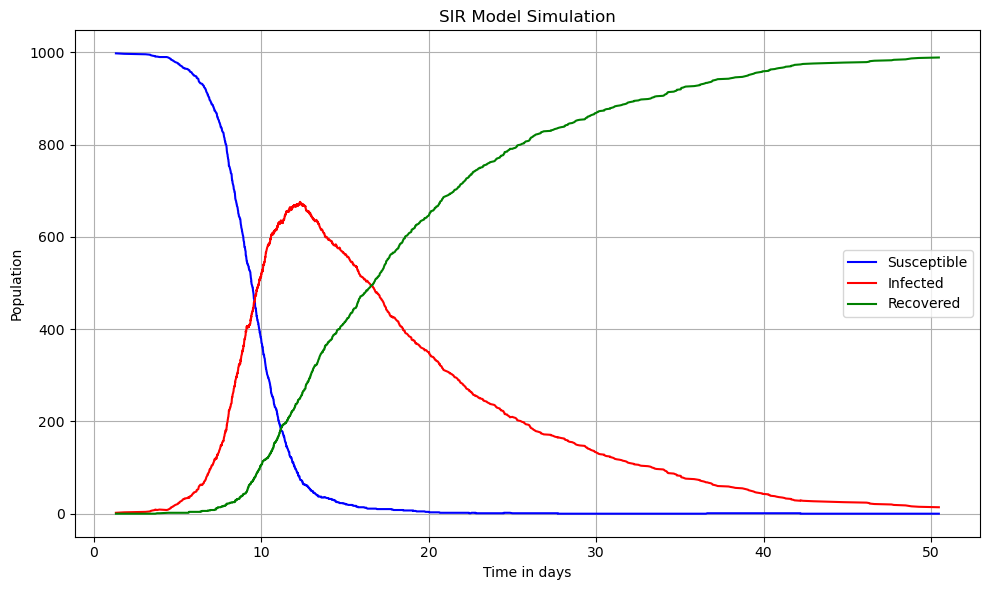

In [21]:
# TEST plot result
initialize_plot()
plot_single_result(result)
add_description_to_plot()
# save_plot('testin_single_plot')
show_plot()

In [22]:
# TEST run multiple simulations
beta = 1
gamma = 0.1
mu = 0.02/365
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

N = 1e3
initial_values = get_initial_values_dict(N)

end_time = 50
no_runs = 50

results = run_multiple_simulations(params, initial_values, end_time, no_runs)

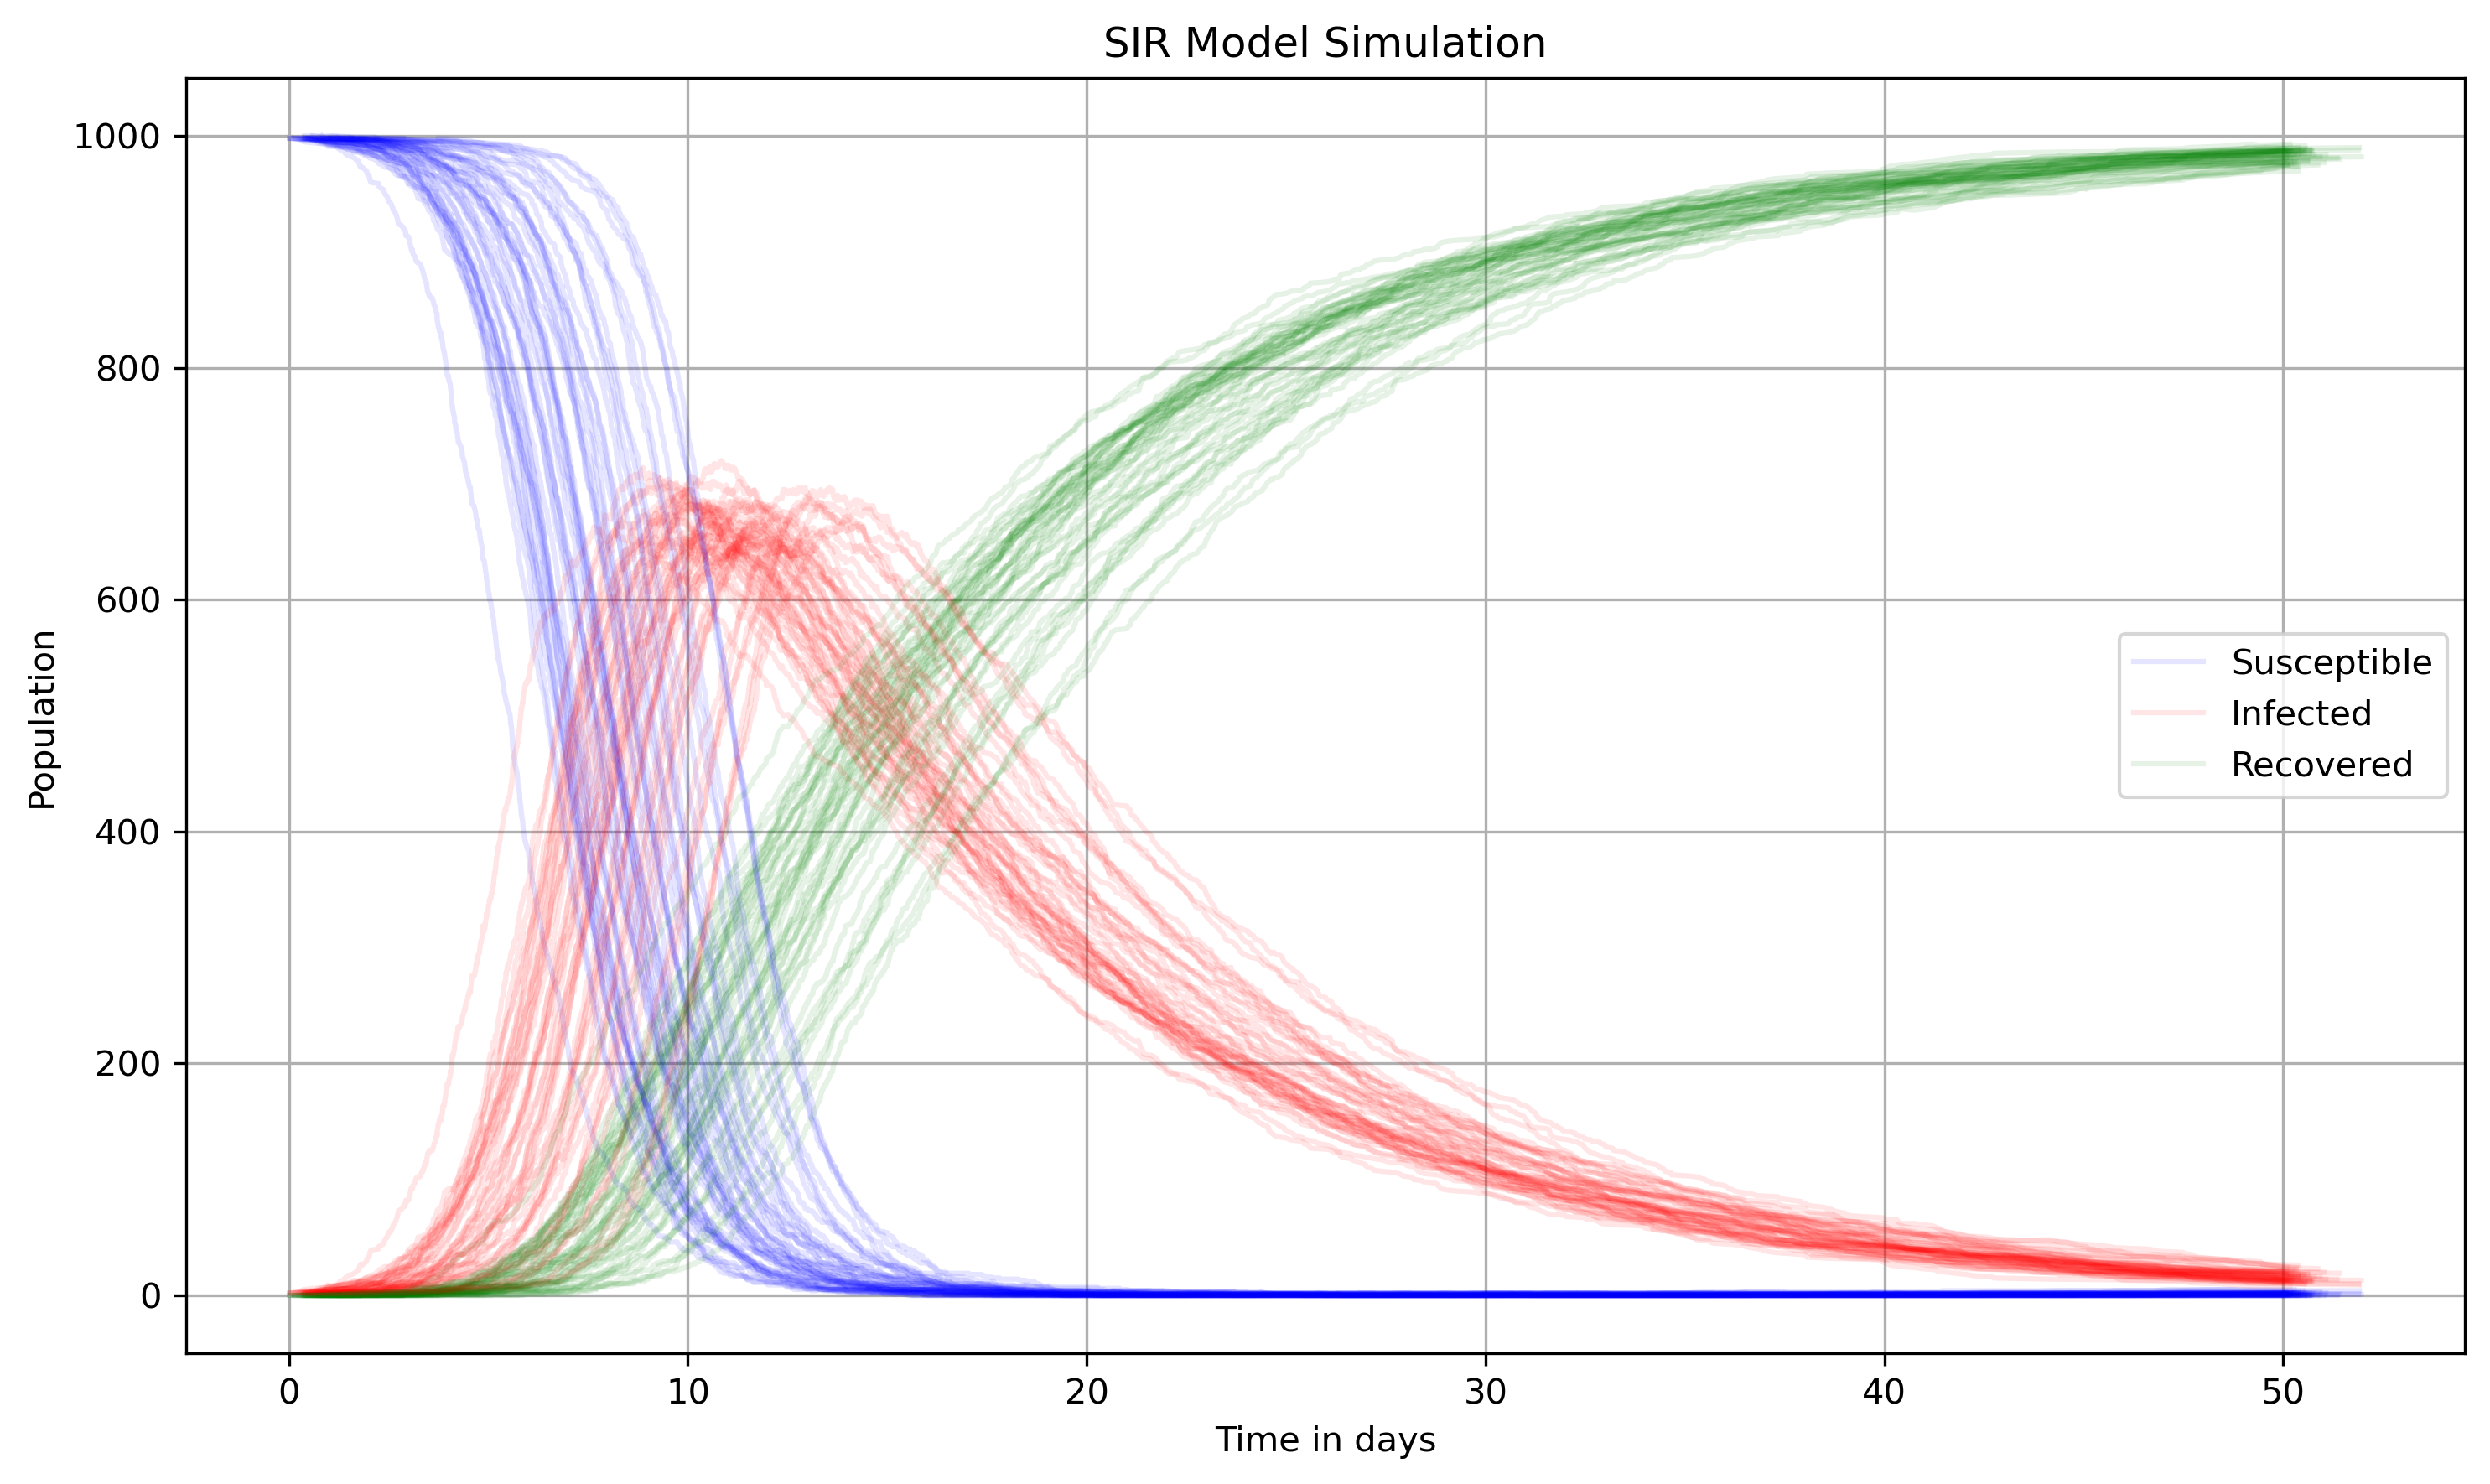

In [23]:
# TEST plot multiple simulations
initialize_plot()
plot_multiple_results(results)
add_description_to_plot_multiple_simulations()
show_plot()

### Deterministic SIR Model 

In [25]:
def SIR_deterministic(y, t, beta, gamma, mu):
    '''
        Function the returns the set of Ordinary Differential Equations that govern the evolution of Susceptible , Infected , Recovered population 
        Parameters:
        y (np.ndarray): 
            Array containing the current state variables [X, Y, Z], where:
            - X: Number of susceptible individuals.
            - Y: Number of infected individuals.
            - Z: Number of recovered individuals.

        t (float): 
            The current time point 

        beta (float): 
            Transmission rate of the infection.

        gamma (float): 
            Recovery rate of infected individuals.

        mu (float): 
            Natural Birth and death rate.
    '''

    X, Y, Z = y
    N = X + Y + Z

    # Define the equations
    dXdt = - ((beta * X * Y )/ N) + (mu * N) - (mu * X)
    dYdt = ((beta * X * Y) / N) - (gamma * Y) - (mu * Y)
    dZdt = (gamma * Y) - (mu * Z)
    
    return [dXdt, dYdt, dZdt]

In [26]:
def solve_SIR_deterministic(params, initial_values, end_time):
    '''
        Function to integrate the system of ODE's over a period of time using initial values and parameters 
        
            Parameters:
                params (dict) : A dictionary containing model parameters:
        
                initial_values (dict) : A dictionary containing the initial population values
        
                end_time (float) : The time up to which the system should be simulated.
        
            Returns:
                solutiont(np.ndarray) : 2D array where each row contains the solution [X, Y, Z] for each time point in the integration.
    '''
    # Prepare time points
    time_points = np.linspace(0, end_time, 100)
    initial_values_array = [initial_values['X'], initial_values['Y'], initial_values['Z']]

    # Run solver
    solution = odeint(SIR_deterministic, initial_values_array, time_points, args=(params['beta'], params['gamma'], params['mu']))

    return solution

In [27]:
# TEST solve deterministic SIR
beta = 1
gamma = 0.1
mu = 0.02/365
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

N = 1e3
initial_values = get_initial_values_dict(N)

end_time = 50

deterministic_result = solve_SIR_deterministic(params, initial_values, end_time)

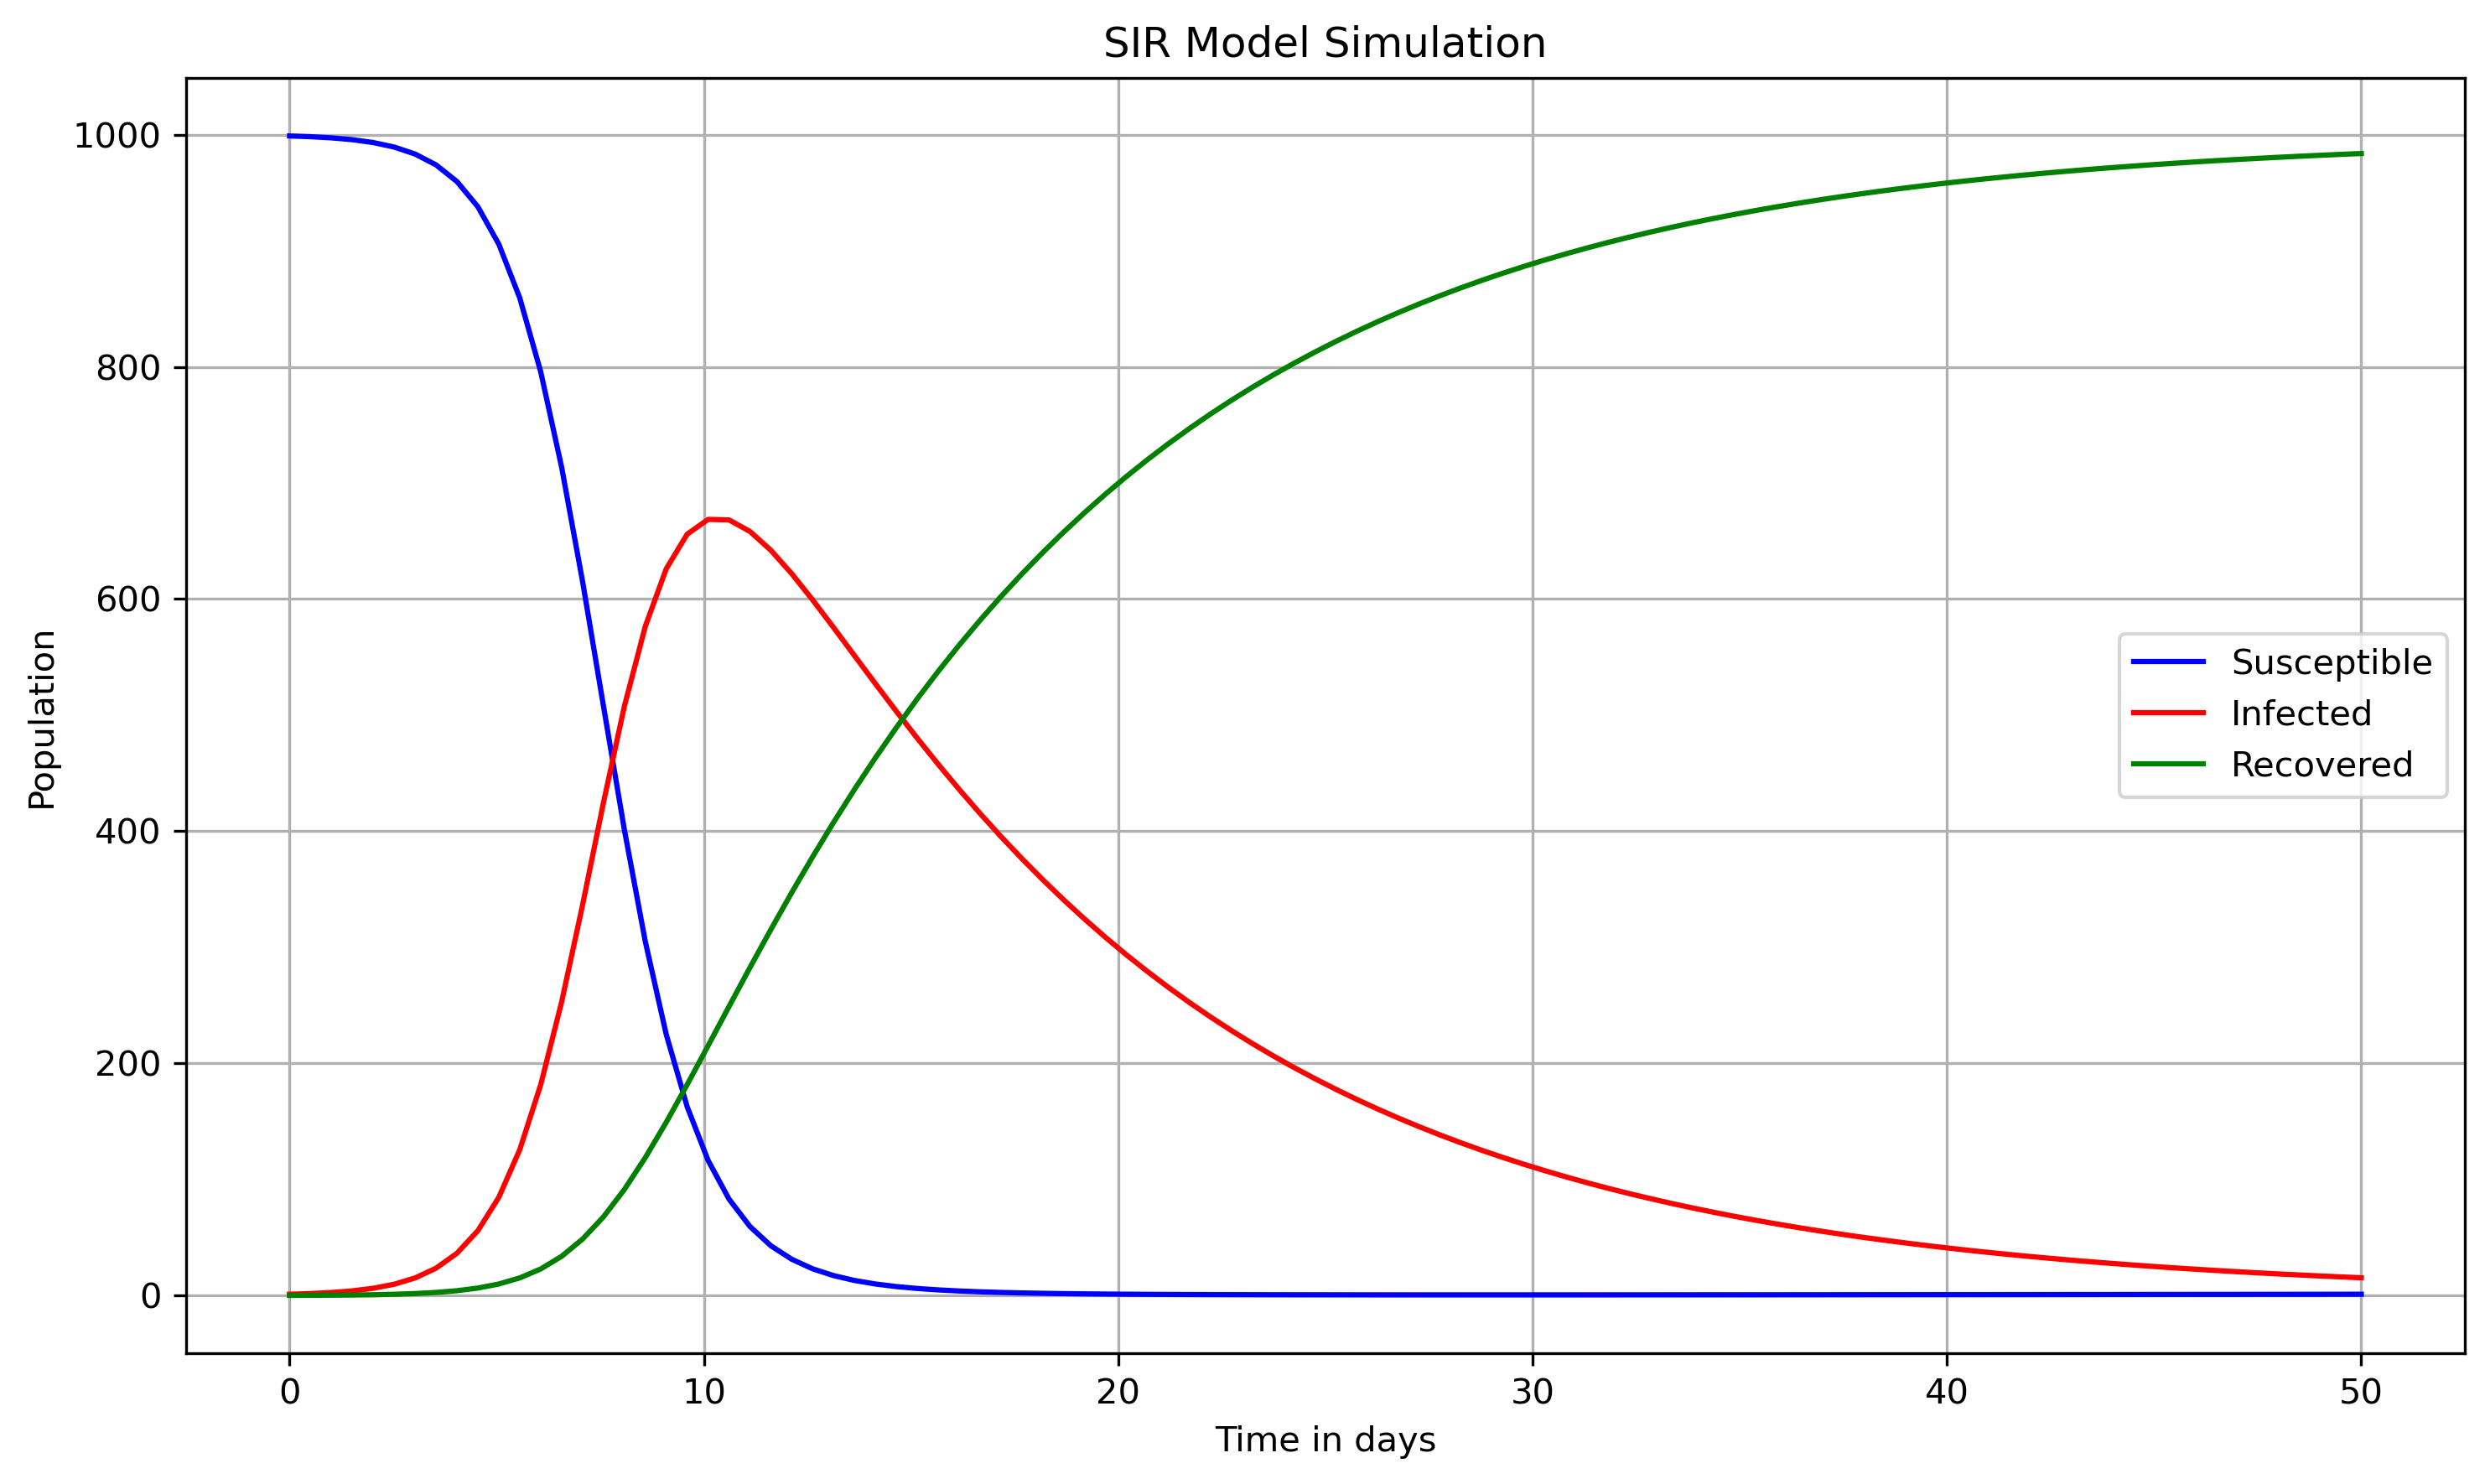

In [28]:
# TEST plot deterministic SIR
deterministic_result_dict = {'time': np.linspace(0, end_time, 100), 'X': deterministic_result[:, 0], 'Y': deterministic_result[:, 1], 'Z': deterministic_result[:, 2]}

initialize_plot()
plot_single_result(deterministic_result_dict)
add_description_to_plot()
# save_plot('testin_single_plot')
show_plot()

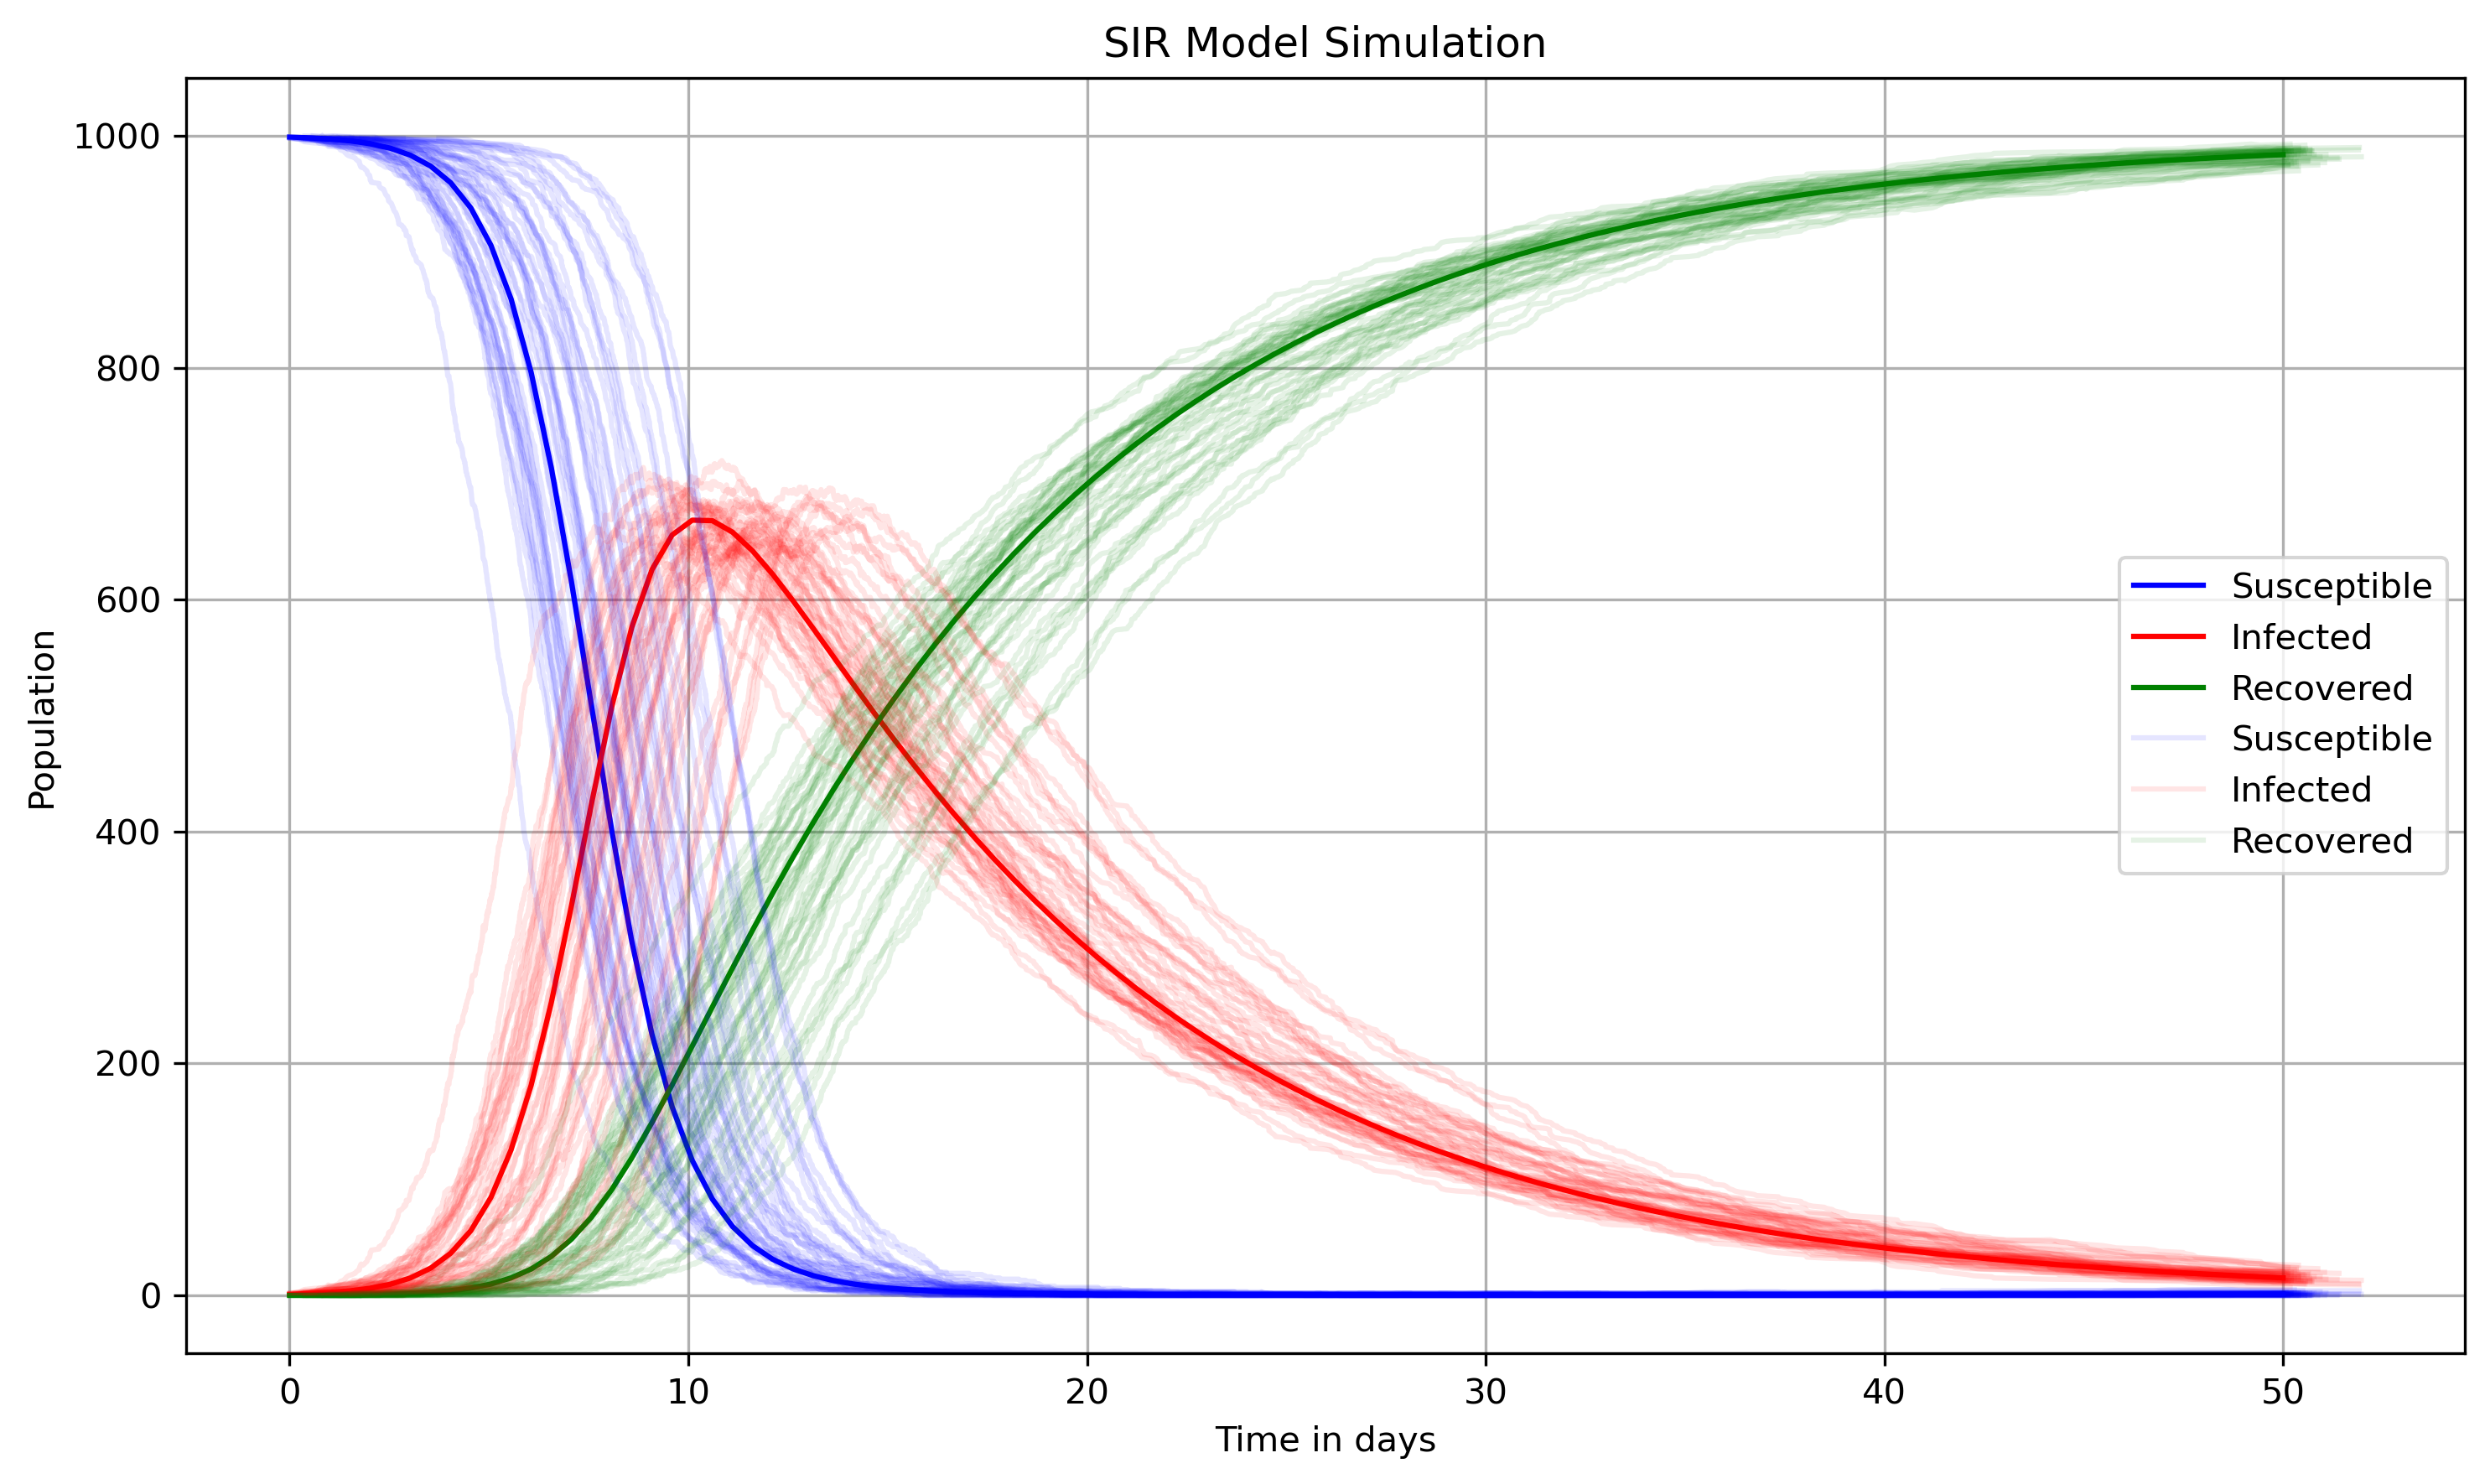

In [29]:
# TEST plot deterministic + multiple simulations
deterministic_result_dict = {'time': np.linspace(0, end_time, 100), 'X': deterministic_result[:, 0], 'Y': deterministic_result[:, 1], 'Z': deterministic_result[:, 2]}

initialize_plot()
plot_single_result(deterministic_result_dict)
plot_multiple_results(results)
add_description_to_plot()
# save_plot('testin_single_plot')
show_plot()

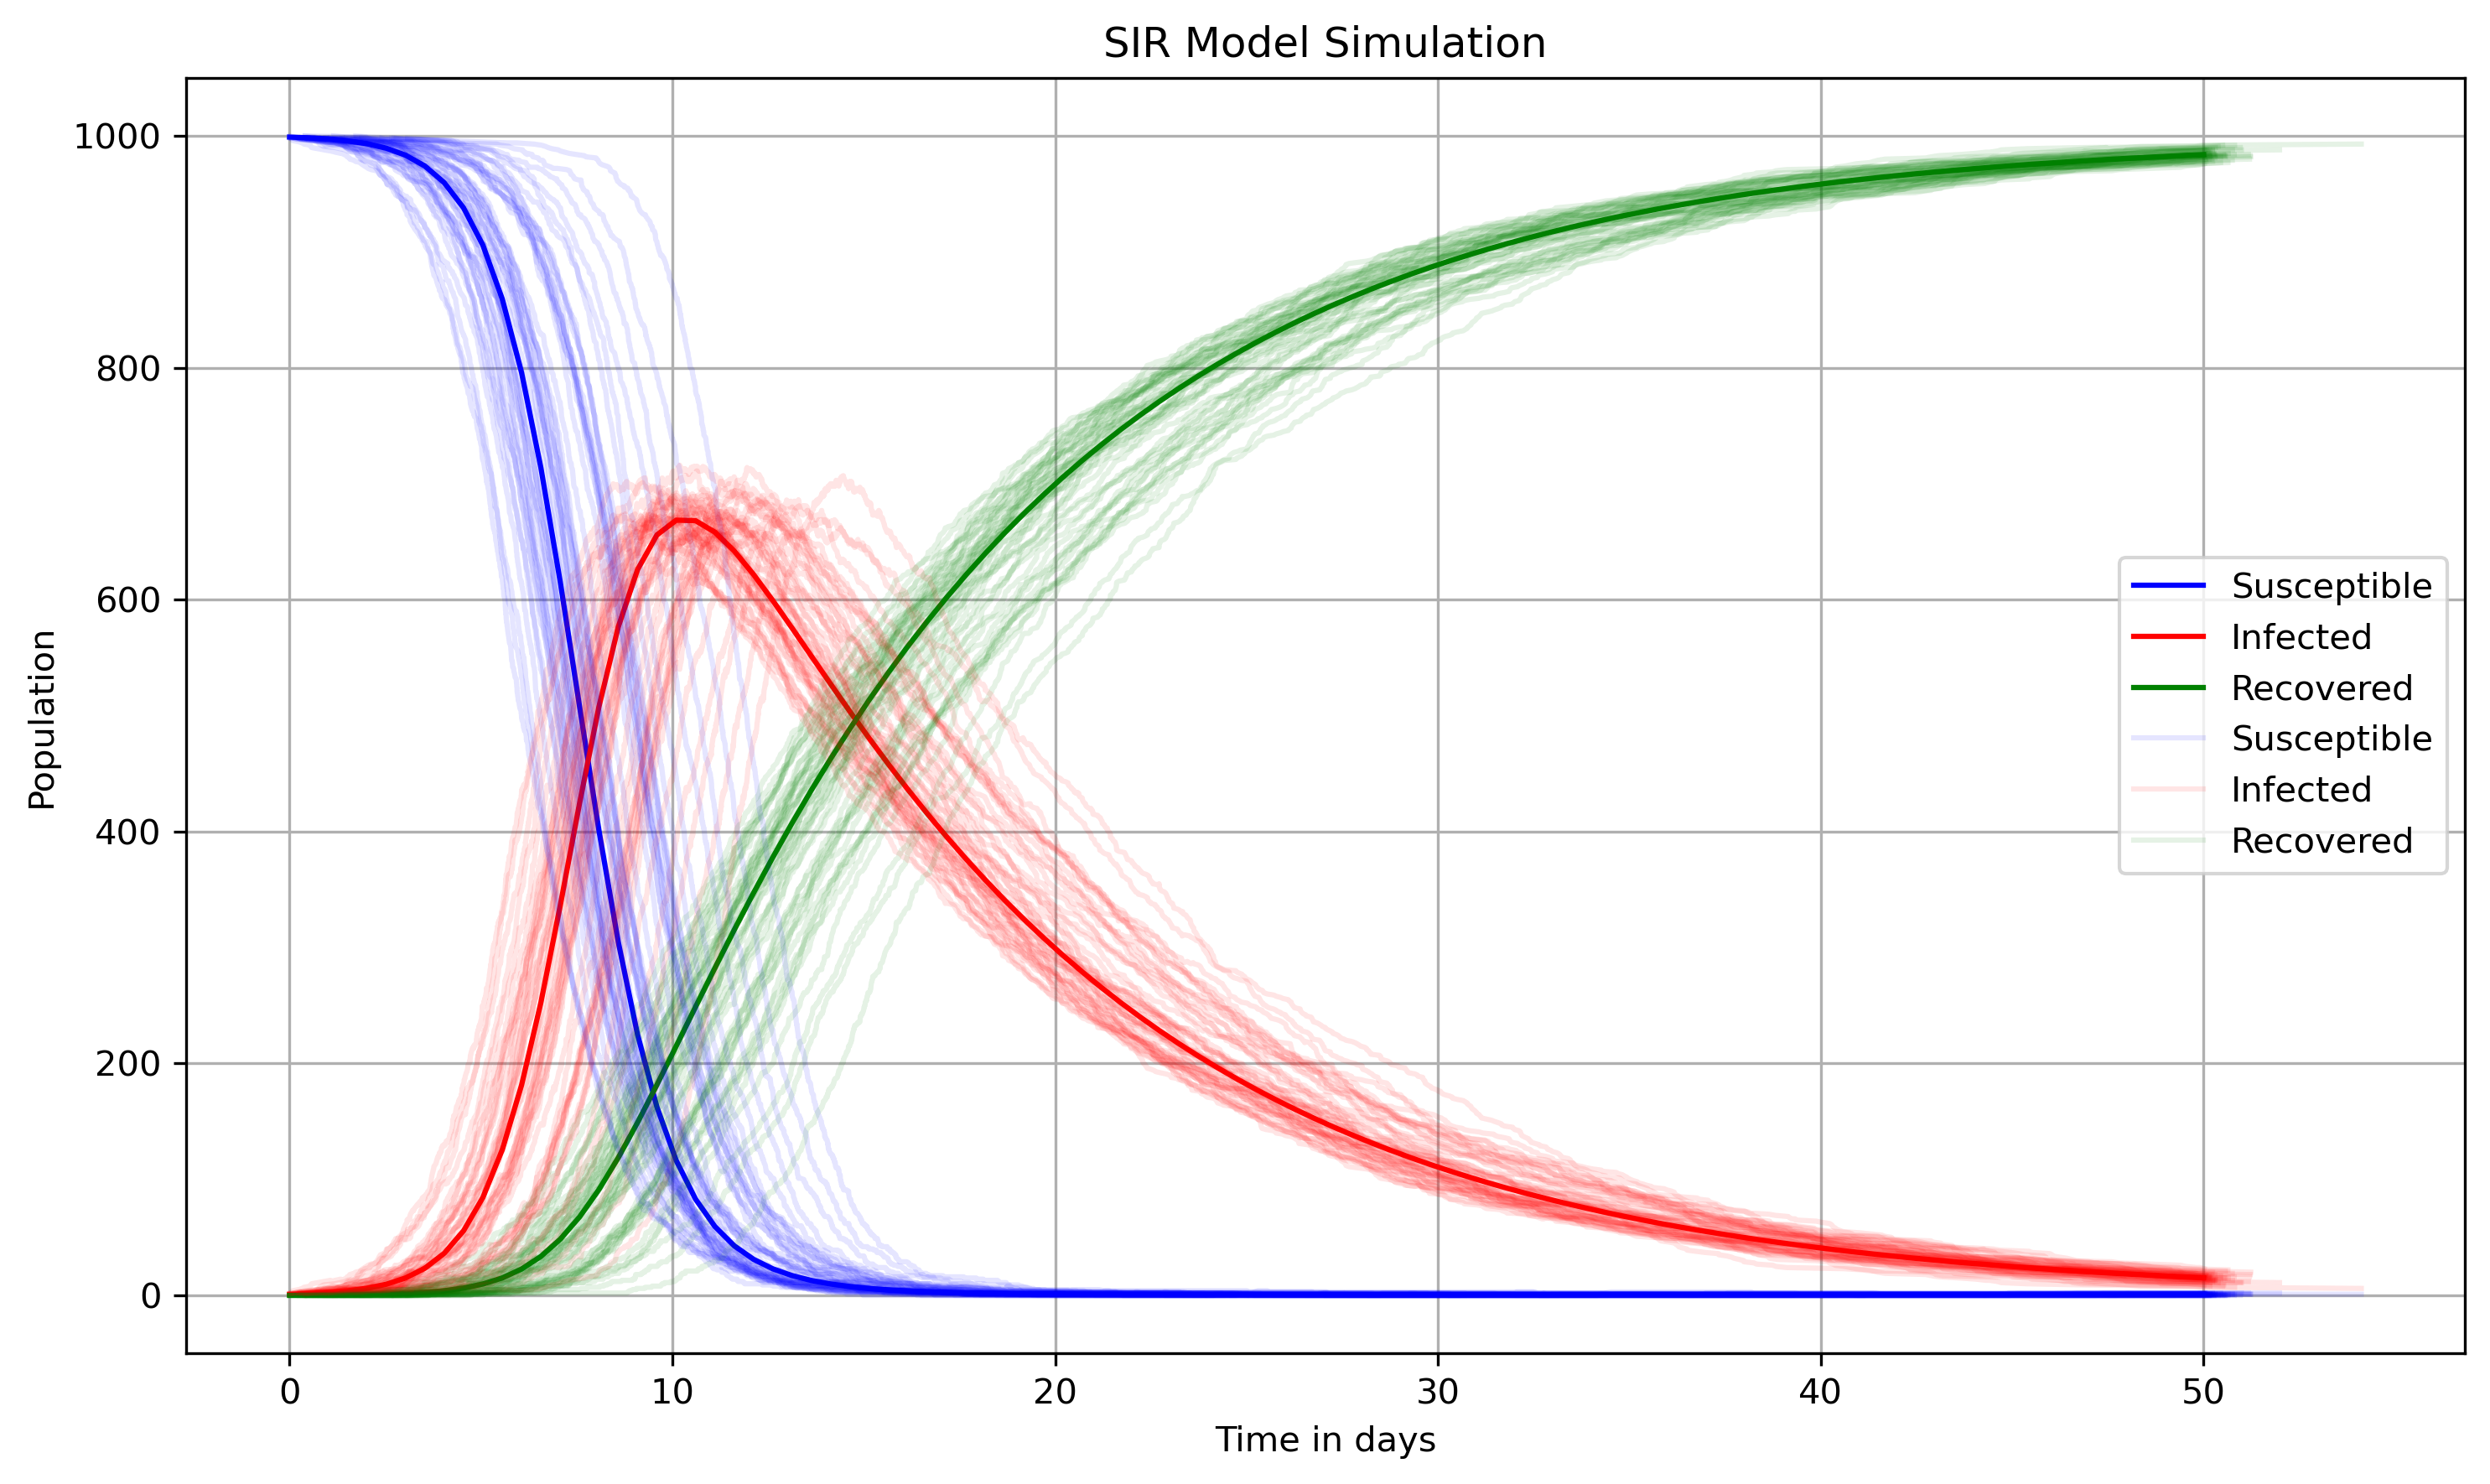

In [30]:
# TEST run multiple simulations + deterministic
beta = 1
gamma = 0.1
mu = 0.02/365
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

N = 1e3
initial_values = get_initial_values_dict(N)

end_time = 50
no_runs = 50

# Solve
results = run_multiple_simulations(params, initial_values, end_time, no_runs)
deterministic_result = solve_SIR_deterministic(params, initial_values, end_time)

# Plot
deterministic_result_dict = {'time': np.linspace(0, end_time, 100), 'X': deterministic_result[:, 0], 'Y': deterministic_result[:, 1], 'Z': deterministic_result[:, 2]}

initialize_plot()
plot_single_result(deterministic_result_dict)
plot_multiple_results(results)
add_description_to_plot()
show_plot()

## Problem 1.2 Variance, covariance, mean

In [179]:
def get_variance_covariance_mean(params, N, end_time, no_runs):
    # Get initial values
    initial_values = get_initial_values_dict(N)

    # Prepare time grid for interpolation
    num_points = 50
    time_grid = np.linspace(0, end_time, num_points)

    # Initialize lists to store interpolated results for each run
    X_values, Y_values, Z_values = [], [], []

    # Run the simulations
    results = run_multiple_simulations(params, initial_values, end_time, no_runs)

    # Get interpolated values for points in time grid
    for result in results:
        # Remove the results where the population got extinct after only a few time steps
        if result['extinction']:
            continue

        # Add the interpolated values
        X_values.append(np.interp(time_grid, result['time'], result['X']))
        Y_values.append(np.interp(time_grid, result['time'], result['Y']))
        Z_values.append(np.interp(time_grid, result['time'], result['Z']))

    # Convert lists to numpy arrays for easier calculations (shape: [run_count, num_points])
    X_values = np.array(X_values)
    Y_values = np.array(Y_values)
    Z_values = np.array(Z_values)

    # Calculate the mean at each time point (over all runs)
    mean_X = np.mean(X_values, axis=0)
    mean_Y = np.mean(Y_values, axis=0)
    mean_Z = np.mean(Z_values, axis=0)

    # Calculate the variance at each time point (over all runs)
    var_X = np.var(X_values, axis=0)
    var_Y = np.var(Y_values, axis=0)
    var_Z = np.var(Z_values, axis=0)

    # Calculate the covariance between S and I at each time point (over all runs)
    cov_XY = np.mean((X_values - mean_X) * (Y_values - mean_Y), axis=0)

    # Return the mean, variance, and covariance results
    return {
        'time_grid': time_grid,
        'mean_X': mean_X,
        'mean_Y': mean_Y,
        'mean_Z': mean_Z,
        'var_X': var_X,
        'var_Y': var_Y,
        'var_Z': var_Z,
        'cov_XY': cov_XY
    }

In [245]:
# TODO: Clean up
def get_mean_Y_from_results(results, end_time, num_points):
     # Prepare time grid for interpolation
    time_grid = np.linspace(0, end_time, num_points)

    # Initialize lists to store interpolated results for each run
    Y_values = []
    
    # Get interpolated values for points in time grid
    for result in results:
        # Remove the results where the population got extinct after only a few time steps
        if result['extinction']:
            continue

        # Add the interpolated values
        Y_values.append(np.interp(time_grid, result['time'], result['Y']))

    # Convert lists to numpy arrays for easier calculations (shape: [run_count, num_points])
    Y_values = np.array(Y_values)

    # Calculate the mean at each time point (over all runs)
    mean_Y = np.mean(Y_values, axis=0)

    return {'time_grid': time_grid, 'mean_Y': mean_Y}

In [181]:
# TEST get_variance_covariance_mean
beta = 1
gamma = 0.1
mu = 0.02/365
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

N = 1e3

end_time = 50
no_runs = 50

statistics = get_variance_covariance_mean(params, N, end_time, no_runs)

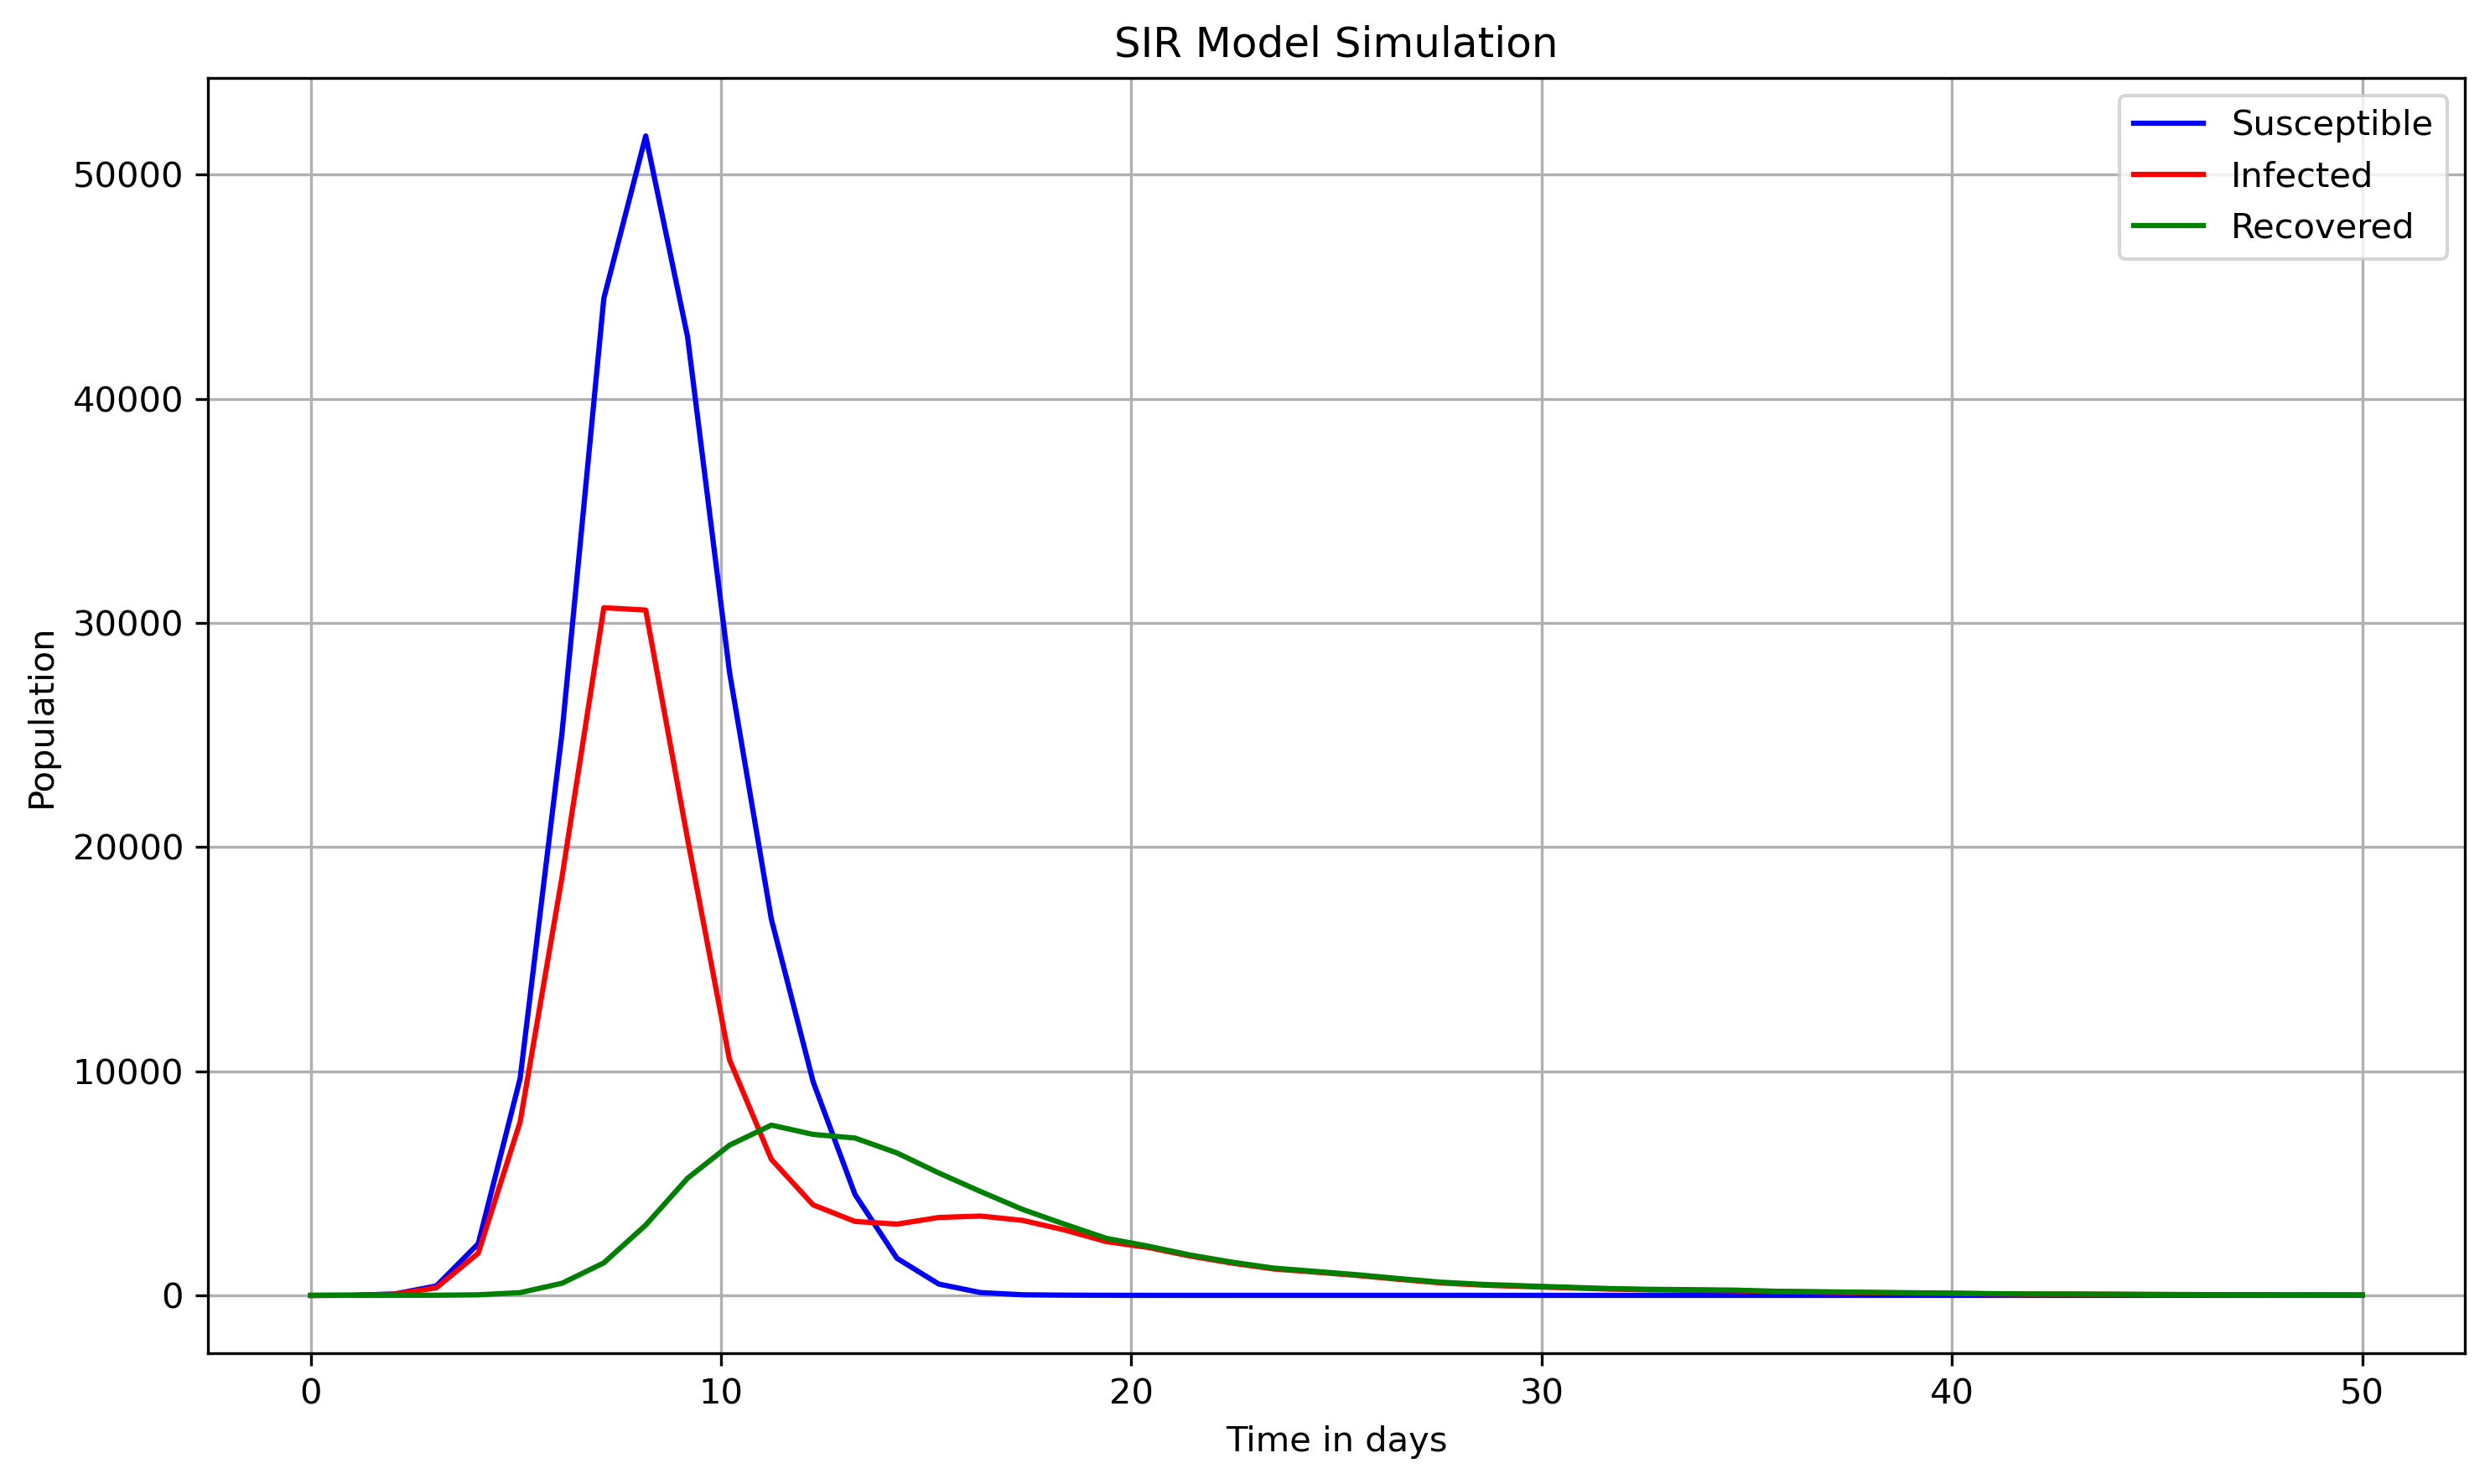

In [183]:
# TEST plot
time_grid = np.linspace(0, end_time, 50)
statistics_dict = {'time': time_grid, 'X': statistics['var_X'], 'Y': statistics['var_Y'], 'Z': statistics['var_Z']}

initialize_plot()
plot_single_result(statistics_dict)
add_description_to_plot()
# save_plot('testin_single_plot')
show_plot()

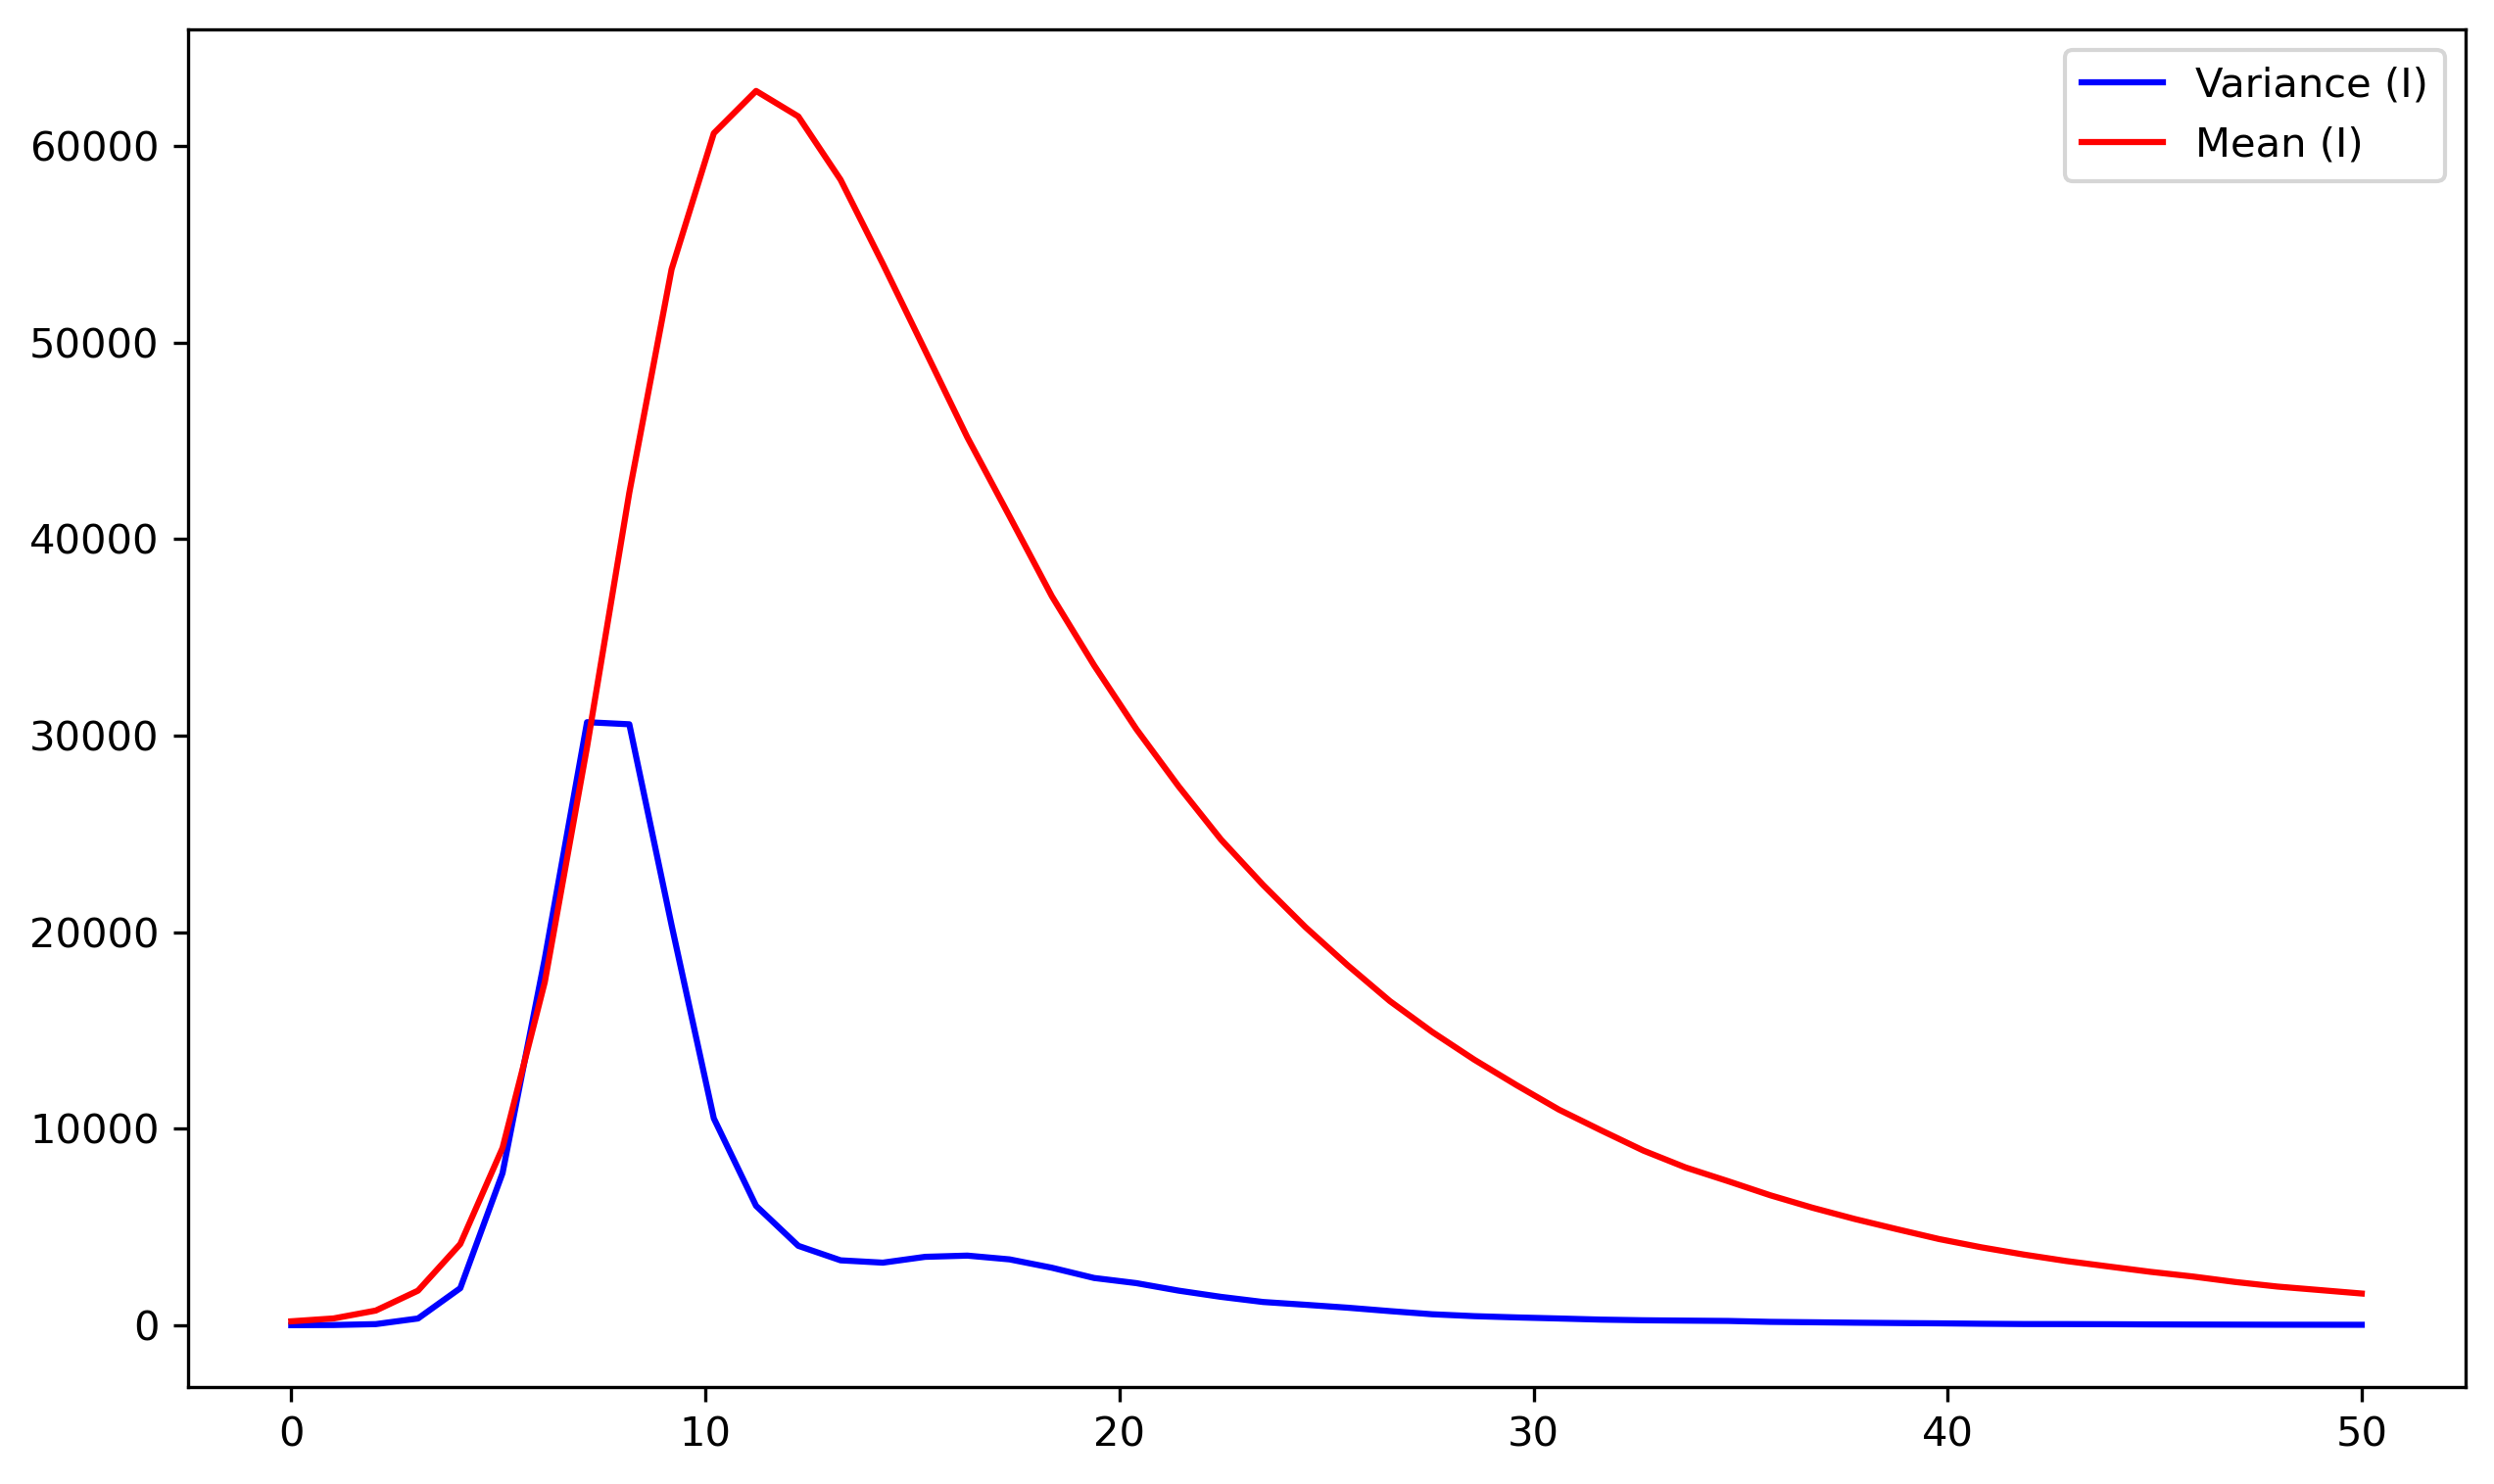

In [185]:
# TEST variance vs mean
initialize_plot()

plt.plot(time_grid, statistics['var_Y'], color='blue', label = 'Variance (I)', linestyle = '-')
plt.plot(time_grid, [mean * 100 for mean in statistics['mean_Y']], color='red', label = 'Mean (I)', linestyle = '-')

plt.legend()

show_plot()

In [187]:
# TEST for different values of N
beta = 1
gamma = 0.1
mu = 0.02/365
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

end_time = 50
no_runs = 50

statistics_1e2 = get_variance_covariance_mean(params, 1e2, end_time, no_runs)
statistics_1e3 = get_variance_covariance_mean(params, 1e3, end_time, no_runs)
statistics_1e4 = get_variance_covariance_mean(params, 1e4, end_time, no_runs)
# statistics_1e5 = get_variance_covariance_mean(params, 1e5, end_time, no_runs)

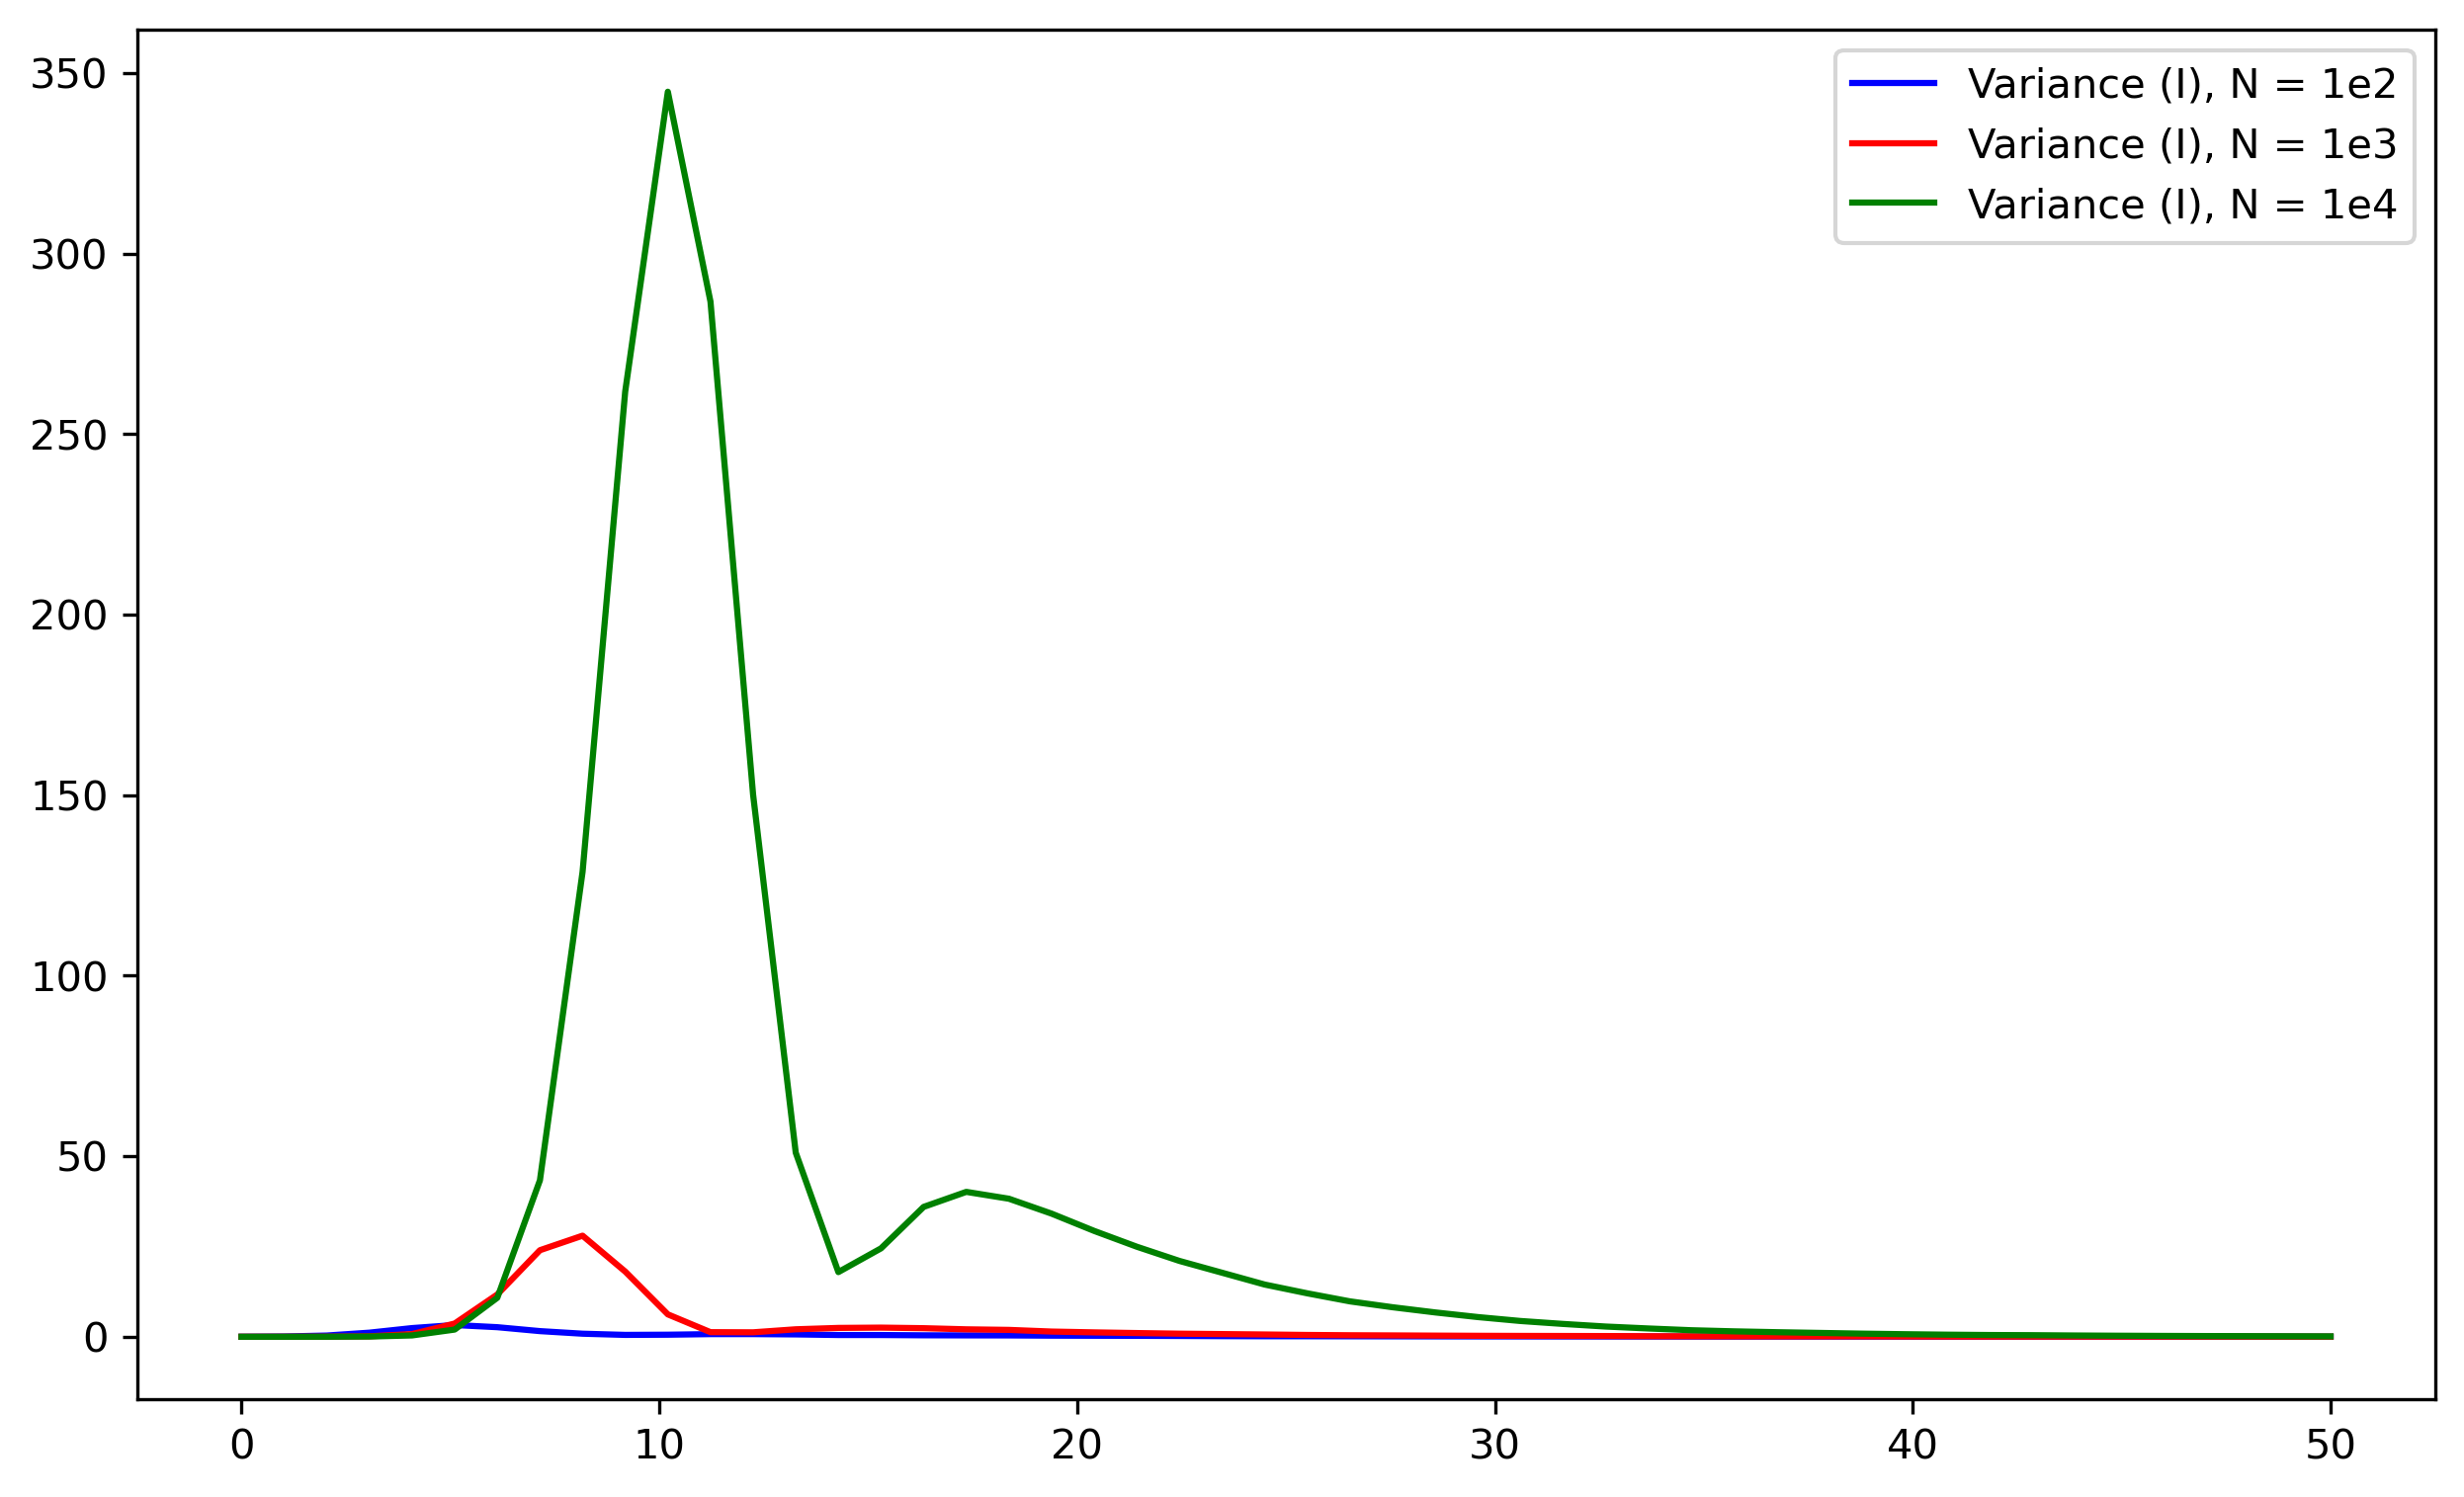

In [37]:
# TEST plot the different variances
initialize_plot()

plt.plot(time_grid, [var/1e2 for var in statistics_1e2['var_Y']], color='blue', label = 'Variance (I), N = 1e2', linestyle = '-')
plt.plot(time_grid, [var/1e3 for var in statistics_1e3['var_Y']], color='red', label = 'Variance (I), N = 1e3', linestyle = '-')
plt.plot(time_grid, [var/1e4 for var in statistics_1e4['var_Y']], color='green', label = 'Variance (I), N = 1e4', linestyle = '-')

plt.legend()

show_plot()

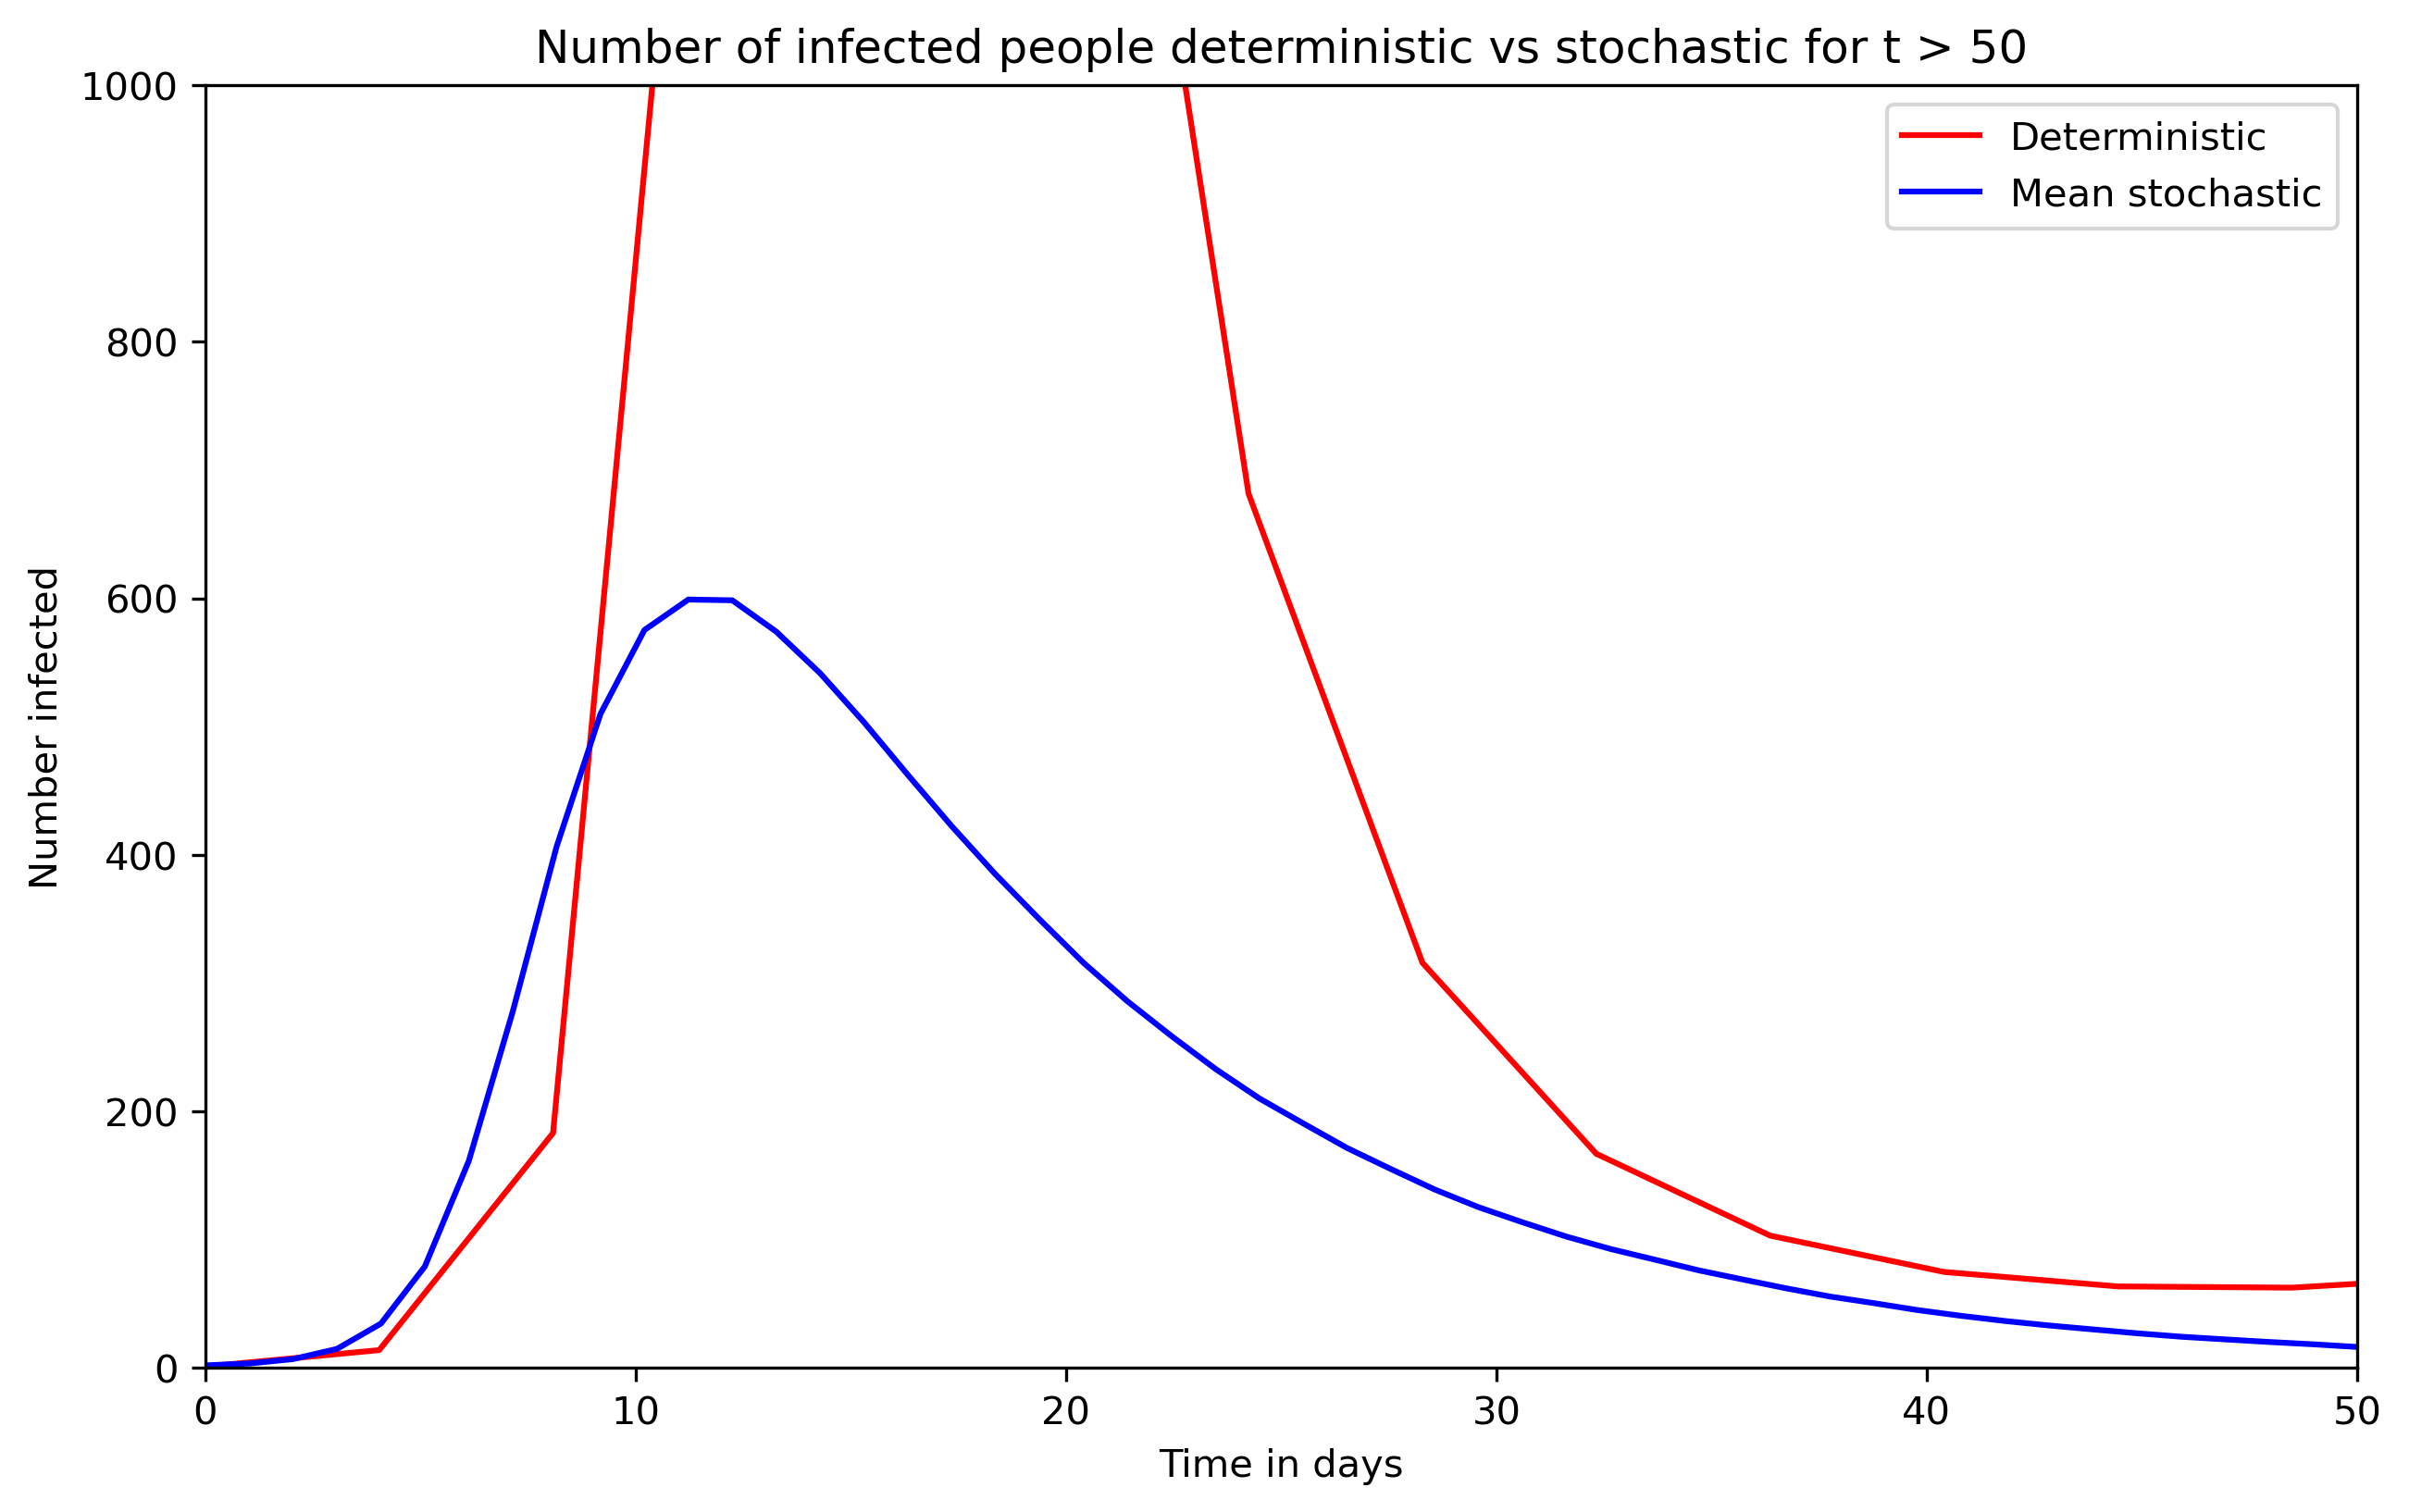

In [249]:
# TODO: Clean up
# Show how the mean changes versus the deterministic mean
beta = 1
gamma = 0.1
mu = 0.02/365
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

end_time = 50
no_runs = 50

N = 1e3
initial_values = get_initial_values_dict(N)

# Solve
results = run_multiple_simulations(params, initial_values, end_time, no_runs)
deterministic_result = solve_SIR_deterministic(params, initial_values, end_time)

num_points = end_time
mean_Y = get_mean_Y_from_results(results, end_time, num_points)

# Plot
initialize_plot()

# Plot deterministic Y
plt.plot(deterministic_result_dict['time'], deterministic_result_dict['Y'], color='red', label = 'Deterministic', linestyle = '-')

# Plot stochastic mean of Y
plt.plot(mean_Y['time_grid'], mean_Y['mean_Y'], color='blue', label = 'Mean stochastic', linestyle = '-')

plt.axis([0, end_time, 0, 1000])
plt.legend()
plt.xlabel('Time in days')
plt.ylabel('Number infected')
plt.title(f'Number of infected people deterministic vs stochastic for t > {start_time}')
show_plot()

## Problem 1.3 Stochastic Resonance and Increased Transients

In [39]:
def combine_stochastic_results(stochastic_results):
    result = {'time': [], 'X': [], 'Y': [], 'Z': []}
    for out in stochastic_results:
        result['time'].extend(out['time'])
        result['X'].extend(out['X'])
        result['Y'].extend(out['Y'])
        result['Z'].extend(out['Z'])
    return result

In [40]:
def get_unique_time_values(result):
    '''
        Function to get unique time points form the simulations 
    '''
    time, unique_indices = np.unique(result['time'], return_index=True)
    X = np.array(result['X'])[unique_indices]
    Y = np.array(result['Y'])[unique_indices]
    Z = np.array(result['Z'])[unique_indices]
    return time, X, Y, Z

In [41]:
def calculate_means(time, X, Y, Z, N):
    meanTime, meanS, meanI, meanR = [], [], [], []
    for i in range(0, len(time) - N + 1, N):
        meanTime.append(np.mean(time[i:i+N]))
        meanS.append(np.mean(X[i:i+N]))
        meanI.append(np.mean(Y[i:i+N]))
        meanR.append(np.mean(Z[i:i+N]))
    return meanTime, meanS, meanI, meanR

In [42]:
def calculate_transients(meanTime, meanI, time, det_results, N):
    '''
        The function computes the transient deviations (differences) between the mean infected population from the stochastic SIR simulations (`meanI`) and the infected population from the deterministic SIR model (`det_I`). The transient deviations are normalized by the stochastic infected population.
        
        Parameters:
        meanTime (List):
            The time points at which the mean values of the stochastic simulations are calculated.
        meanI (List) :
            The mean values of the infected population (I) obtained from the stochastic SIR model.
        time (List):
            The time points corresponding to the deterministic model results.
        det_results (List):
            The solution of the deterministic SIR model, where the second column represents the infected population (I).
        N (int) :
            The chunk size or step size used to group data for averaging purposes.
        
        Returns:
        transients (List):
            A list of the relative transient deviations between the stochastic and deterministic infected populations, normalized by the stochastic infected population.

    '''
    transients = []
    for i in range(0, len(meanTime)):
        total_stochastic = meanI[i]  # Stochastic I only
        det_I = np.interp(meanTime[i], time, det_results[:, 1])  # Interpolating deterministic I

        # Calculate transient deviation as a ratio of the total population
        transient = np.sqrt((meanI[i] - det_I) ** 2)
        relative_transient = transient / total_stochastic if total_stochastic != 0 else 0  # Avoid division by zero
        transients.append(relative_transient)
    return transients

In [43]:
# def calculate_transients(meanTime, meanI, time, det_results, N):
#     transients = []
#     for i in range(1, len(meanTime) - 1):  # Start from 1 and go to len-1 to avoid index out of bounds
#         total_stochastic = meanI[i]  # Stochastic I only
        
#         # Find the index of the current time step and the neighboring points
#         current_time = meanTime[i]
#         idx_before = np.searchsorted(time, current_time, side='left') - 1  # Index of the time just before meanTime[i]
#         idx_after = idx_before + 1  # Index of the time just after meanTime[i]
#         if idx_before < 0:
#             idx_before = 0
#         if idx_after >= len(time):
#             idx_after = len(time) - 1

#         # Average the deterministic I value at the neighboring time points
#         det_I_before = det_results[idx_before, 1]  # I value just before
#         det_I_after = det_results[idx_after, 1]    # I value just after
#         det_I = (det_I_before + det_I_after) / 2   # Approximate I by averaging

#         # Calculate transient deviation as a ratio of the total population
#         transient = np.sqrt((meanI[i] - det_I) ** 2)
#         relative_transient = transient / total_stochastic if total_stochastic != 0 else 0  # Avoid division by zero
#         transients.append(relative_transient)
    
#     return transients


In [44]:
def plot_transients(meanTime, transients):
    '''
    Function plots the Relative Transient Deviation  from Deterministic Equilibrium  
    '''
    initialize_plot()
    plt.plot(meanTime, transients, label='Relative Transient Deviations', linestyle='-')
    plt.xlabel('Time')
    plt.ylabel('Transient Deviation (Normalized by Population)')
    plt.title('Relative Transient Deviations from Deterministic Equilibrium')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    show_plot()

In [45]:
def process_stochastic_results(stochastic_results, time_points, det_results, initial):
    '''
    Function combines the results from multiple stochastic runs, calculates the mean values of susceptible, infected, and recovered populations, and computes
    the transient deviations between the stochastic and deterministic solutions
    Parameters:
        stochastic_results (list of dict):
            List where each element is a dictionary containing time points and corresponding 
            population values (X, Y, Z) from individual stochastic simulation runs

        time_points (np.ndarray):
            NumPy array of time points corresponding to the deterministic solution

        det_results (np.ndarray):
            NumPy array where each row contains the deterministic solution for susceptible (X),
            infected (Y), and recovered (Z) populations at different time points

    '''
    
    # Combine results from all stochastic runs
    combined_results = combine_stochastic_results(stochastic_results)

    # Get unique time points and corresponding values
    time, X, Y, Z = get_unique_time_values(combined_results)

    # Calculate mean values
    N_chunk = math.ceil(sum(initial.values()) / 100)  # Adjust chunk size based on initial values
    meanTime, meanS, meanI, meanR = calculate_means(time, X, Y, Z, N_chunk)

    # Calculate transients
    transients = calculate_transients(meanTime, meanI, time_points, det_results, N_chunk)

    print(f"Average relative transient: {np.mean(transients)}")
    plot_transients(meanTime, transients)

In [46]:
def SIR_stoch_run_with_transients(beta=1, X=999):
    '''
        Runs the SIR stochastic model multiple times and compares the results with the deterministic model to calculate transient deviations.
        Parameters:
        beta (float): optional parameter 
            The transmission rate parameter for the disease. Default is set to 1 .
        X (int): optional parameter
            The initial number of susceptible individuals (S) in the population. Default is set to 999 .
    '''
    params = {
        'beta': beta,  
        'gamma': 0.1,
        'mu': 0.02 / 365
    }
    initial = {
        'X': X,     
        'Y': 1,     
        'Z': 0      
    }
    
    end_time = 50  # end of simulation time span starting at 0
    run_count = 50 # number of runs

    # Solve the deterministic model and retrieve the solution
    det_results = solve_SIR_deterministic(params, initial, end_time)
    time_points = np.linspace(0, end_time, 100)

    # Run stochastic simulations
    stochastic_results = run_multiple_simulations(params, initial, end_time, run_count)

    # Process stochastic results to calculate transients
    process_stochastic_results(stochastic_results, time_points, det_results, initial)

Average relative transient: 0.14499869224571682


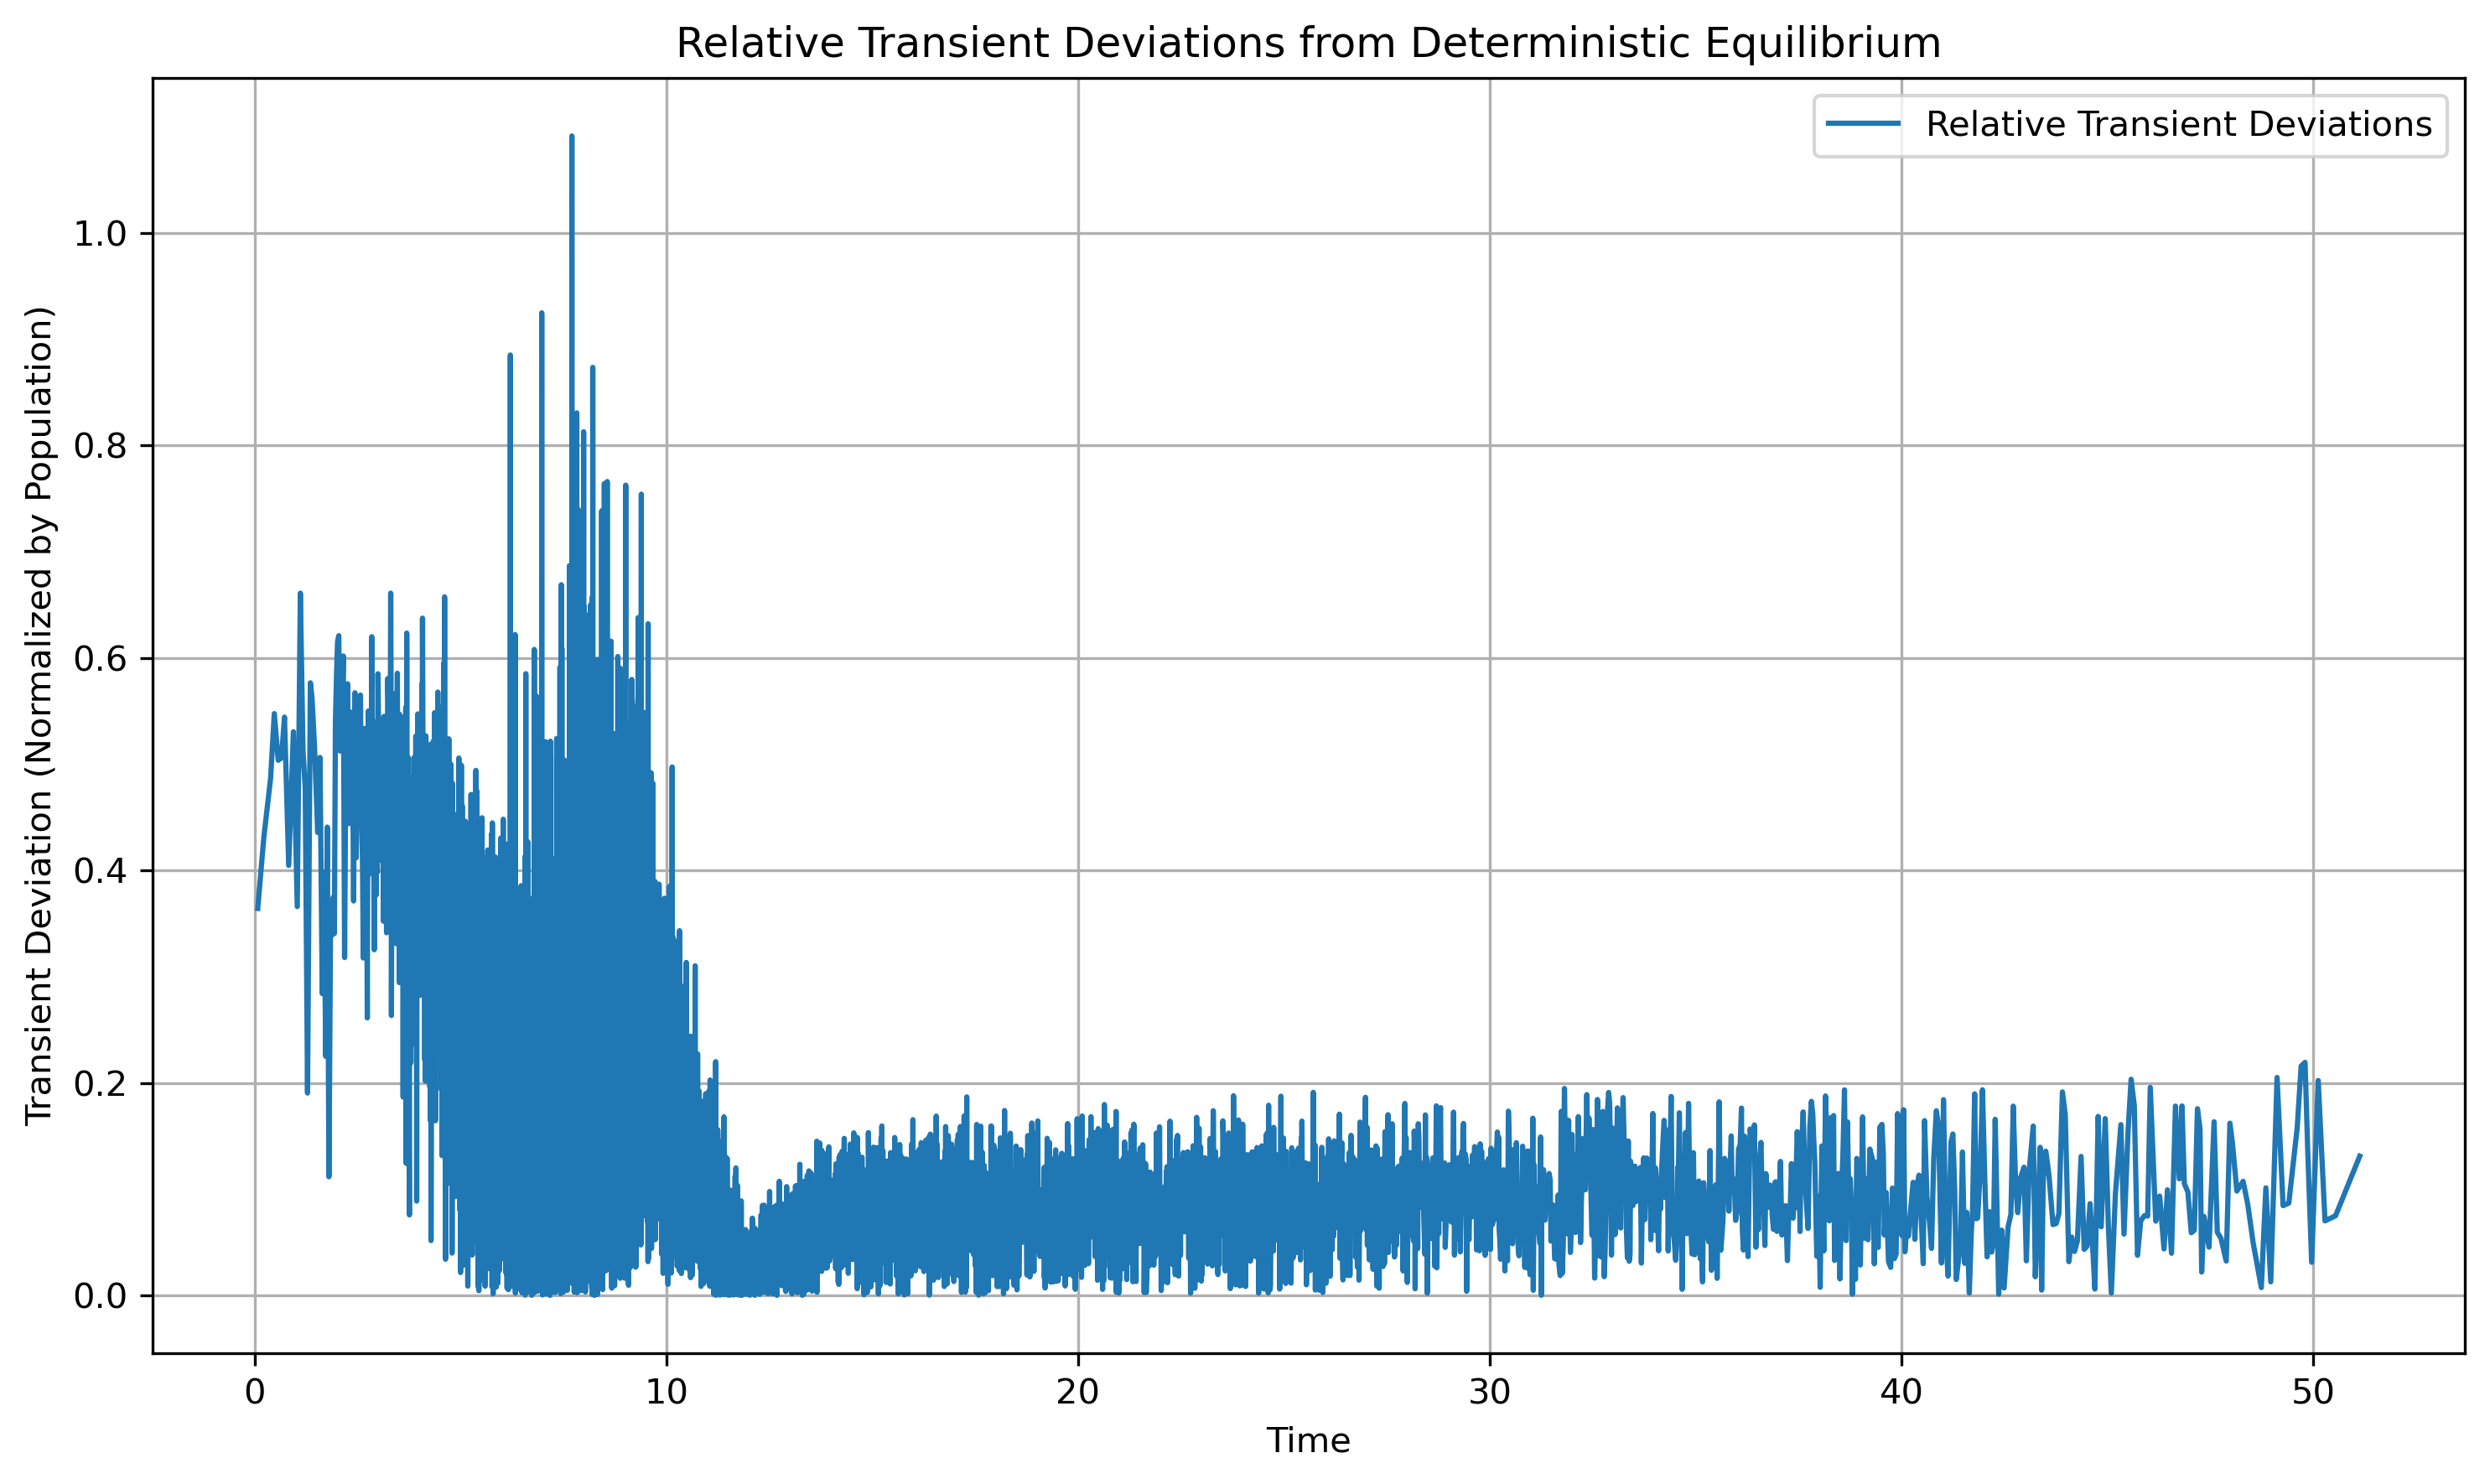

In [47]:
SIR_stoch_run_with_transients()

### Problem 1.3 Stochastic Resonance

In [241]:
# TODO: Clean up
# Run multiple simulations for longer time and do not include the beginning of the epidemics
# Test with parameter values that generate oscillations
beta = 1
gamma = 1/3
mu = 1/60
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

N = 1e4
initial_values = get_initial_values_dict(N)

end_time = 400
no_runs = 50

# Solve
results = run_multiple_simulations(params, initial_values, end_time, no_runs)
deterministic_result = solve_SIR_deterministic(params, initial_values, end_time)

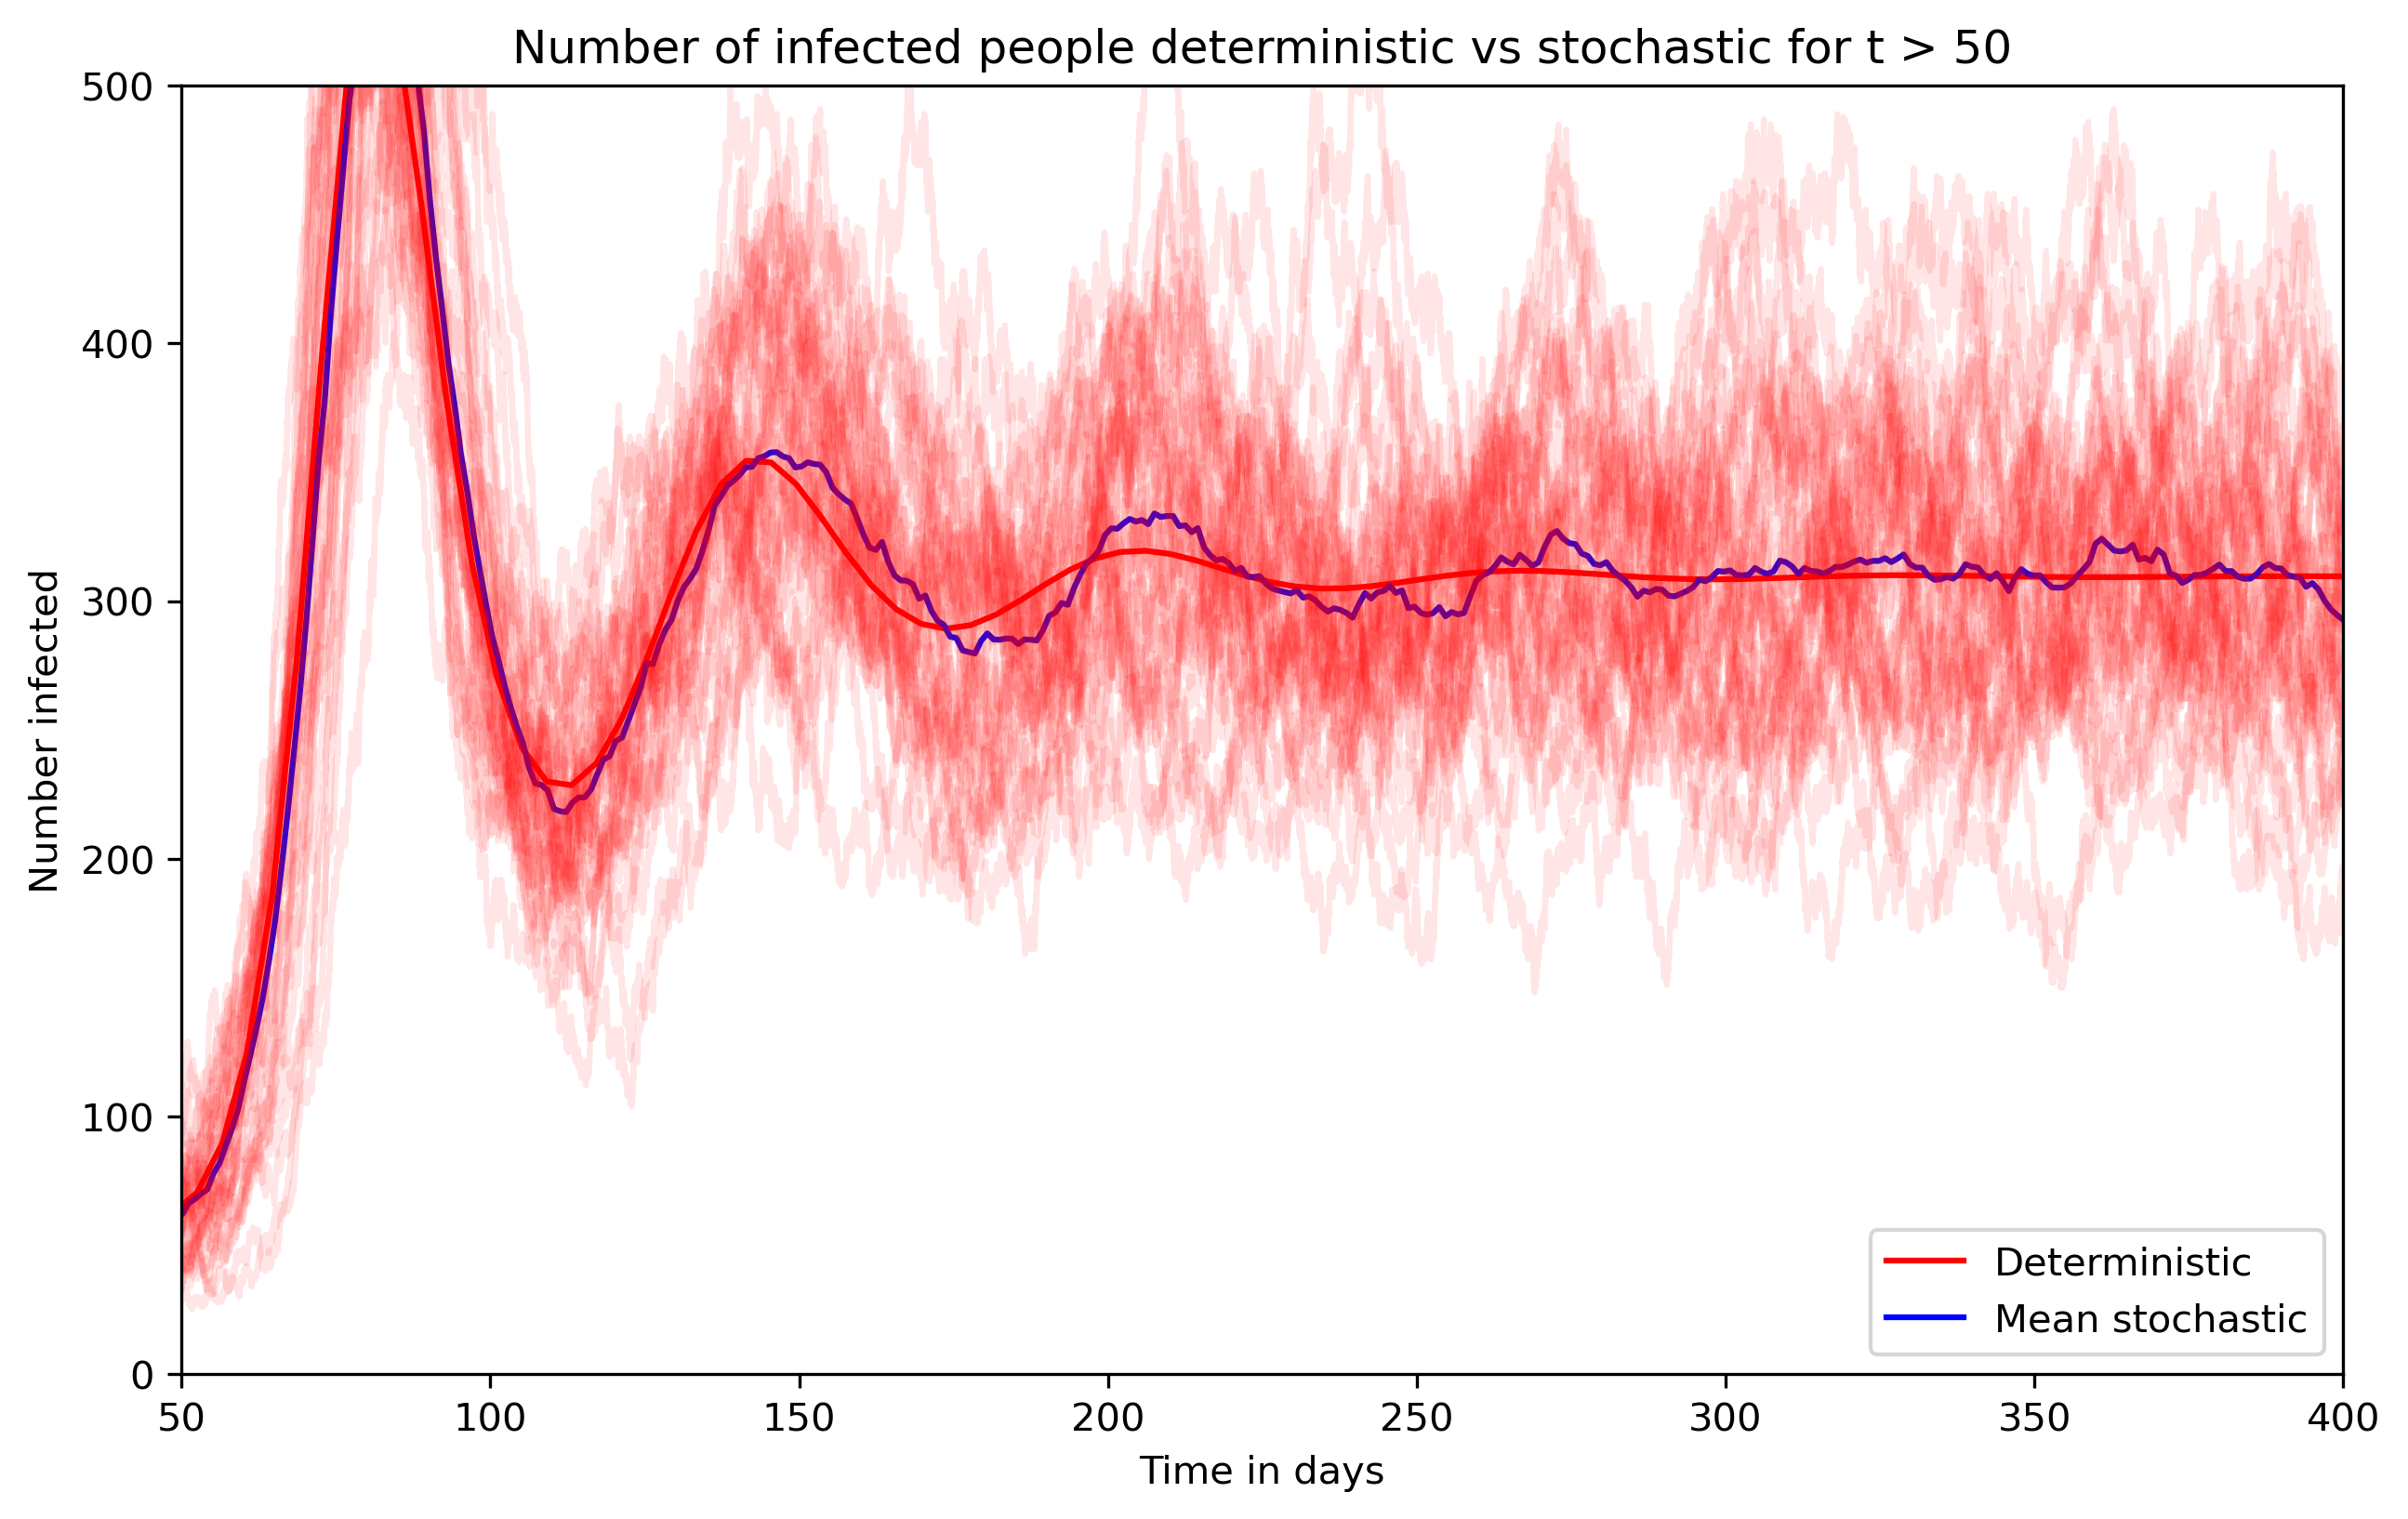

In [242]:
# TODO: Clean up
# Plot
deterministic_result_dict = {'time': np.linspace(0, end_time, 100), 'X': deterministic_result[:, 0], 'Y': deterministic_result[:, 1], 'Z': deterministic_result[:, 2]}

start_time = 50
num_points = end_time

mean_Y = get_mean_Y_from_results(results, end_time, num_points)

initialize_plot()

# Plot deterministic Y
plt.plot(deterministic_result_dict['time'], deterministic_result_dict['Y'], color='red', label = 'Deterministic', linestyle = '-')

# Plot stochastic mean of Y
plt.plot(mean_Y['time_grid'], mean_Y['mean_Y'], color='blue', label = 'Mean stochastic', linestyle = '-')

# Plot stochastic Y
for result in results:
    plt.plot(result['time'], result['Y'], color='red', alpha=0.1)

plt.axis([start_time, end_time, 0, 500])
plt.legend()
plt.xlabel('Time in days')
plt.ylabel('Number infected')
plt.title(f'Number of infected people deterministic vs stochastic for t > {start_time}')
show_plot()

## Problem 1.4 Extinction events and Critical Community Size

In [49]:
def get_number_of_extinctions(N, params, end_time, no_runs):
    initial_values = get_initial_values_dict(N)

    results = run_multiple_simulations(params, initial_values, end_time, no_runs)
    
    no_extinctions = 0
    
    for result in results:
        if result['extinction'] == True:
            no_extinctions += 1

    return no_extinctions

In [50]:
# TEST get_number_of_extinctions and save in matrix to be able to plot it
betas = np.linspace(0.1, 2, 20)
gamma = 0.1
mu = 0.02/365

N = [1e0, 1e1, 1e2, 1e3] # TODO: add 1e4

end_time = 50
no_runs = 100

extinctions = np.zeros((len(betas), len(N)))

for i, beta in enumerate(betas):
    params = {'beta': beta, 'gamma': gamma, 'mu': mu}
    R_0 = beta/gamma   

    for j, n in enumerate(N): 
        no_extinctions = get_number_of_extinctions(n, params, end_time, no_runs)

        extinctions[i][j] = no_extinctions

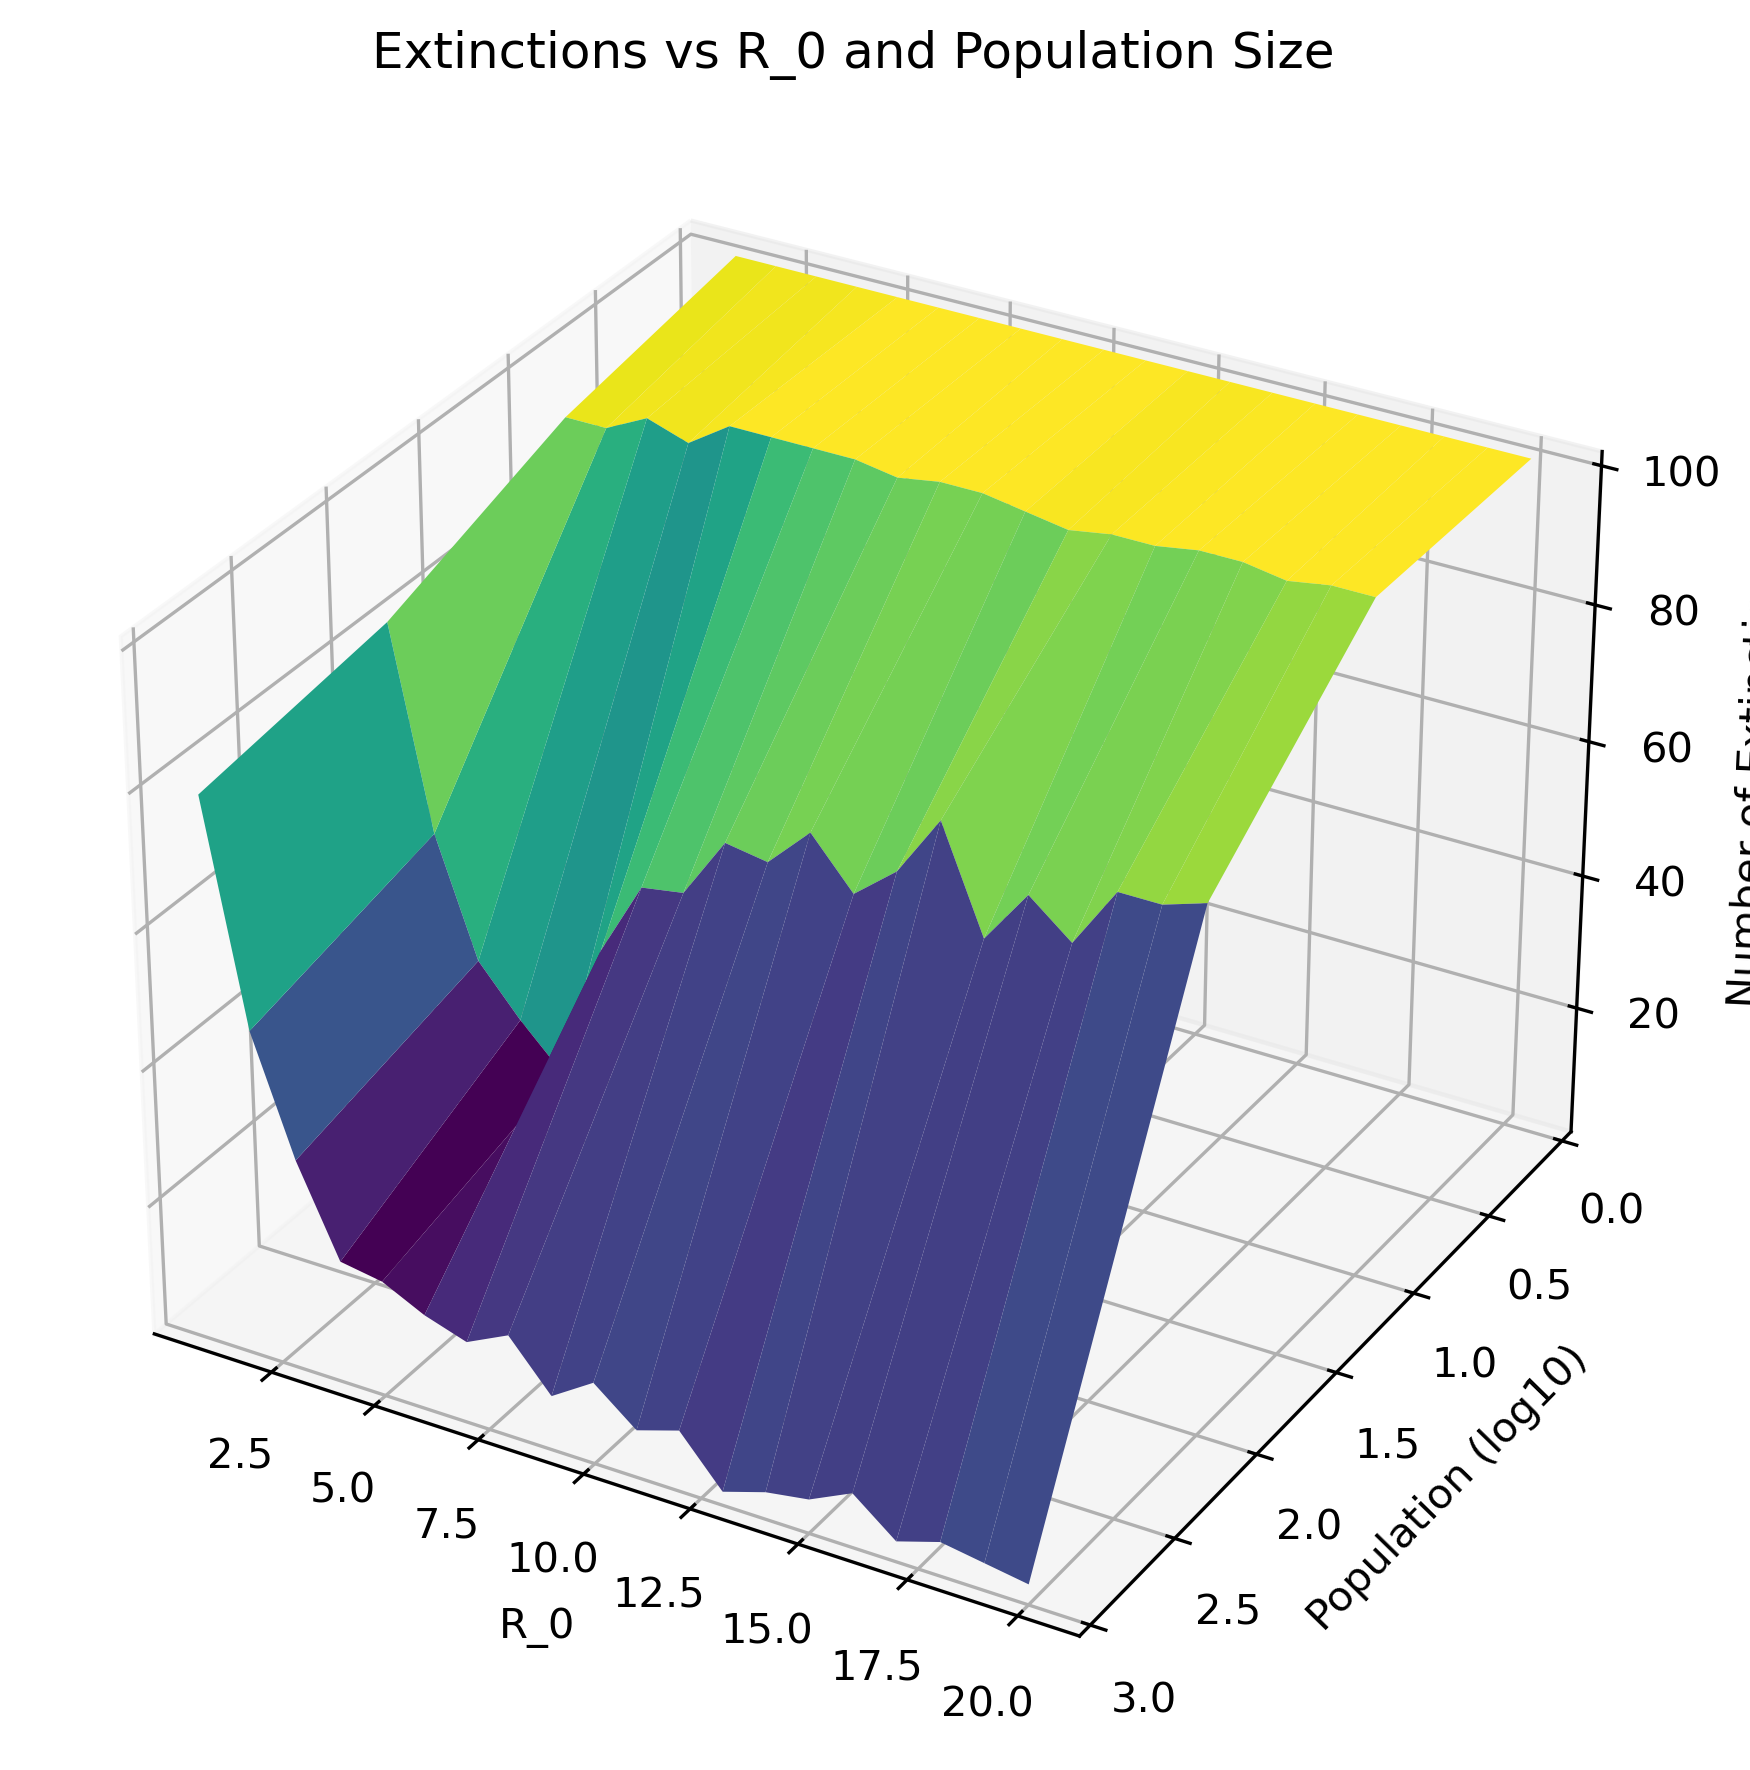

In [51]:
# PLOTTING R_0 INSTEAD OF BETA
# Convert N to a logarithmic scale for plotting
log_N = np.log10(N)

# Get R_0 frome betas
gamma = 0.1
R_0 = [beta/gamma for beta in betas]

# Create a 2D grid of betas and log_N for plotting
R_0_mesh, LogN = np.meshgrid(R_0, log_N)

# Plotting the 3D surface plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(R_0_mesh, LogN, extinctions.T, cmap='viridis')  # Transpose the extinction matrix

# Set labels and title
ax.set_xlabel('R_0')
ax.set_ylabel('Population (log10)')
ax.set_zlabel('Number of Extinctions')
ax.set_title('Extinctions vs R_0 and Population Size')

ax.set_ylim(max(log_N), min(log_N)) # Reverse N to go from large to small

plt.tight_layout()
# plt.savefig(rf'testing_3d.png', dpi=300)
plt.show()

### Testing extinction with time

In [53]:
def get_number_of_extinctions_time_series(N, params, end_time, no_runs):
    initial_values = get_initial_values_dict(N)

    results = run_multiple_simulations(params, initial_values, end_time, no_runs)
    
    time = {} # Dict containing the times and how many extinctions happened at each time
    
    for result in results:
        if result['extinction'] == True:
            if result['extinction_time'] in time:
                time[result['extinction_time']] += 1
            else:
                time[result['extinction_time']] = 1

    return time

The total time in seconds:
131.19687724113464


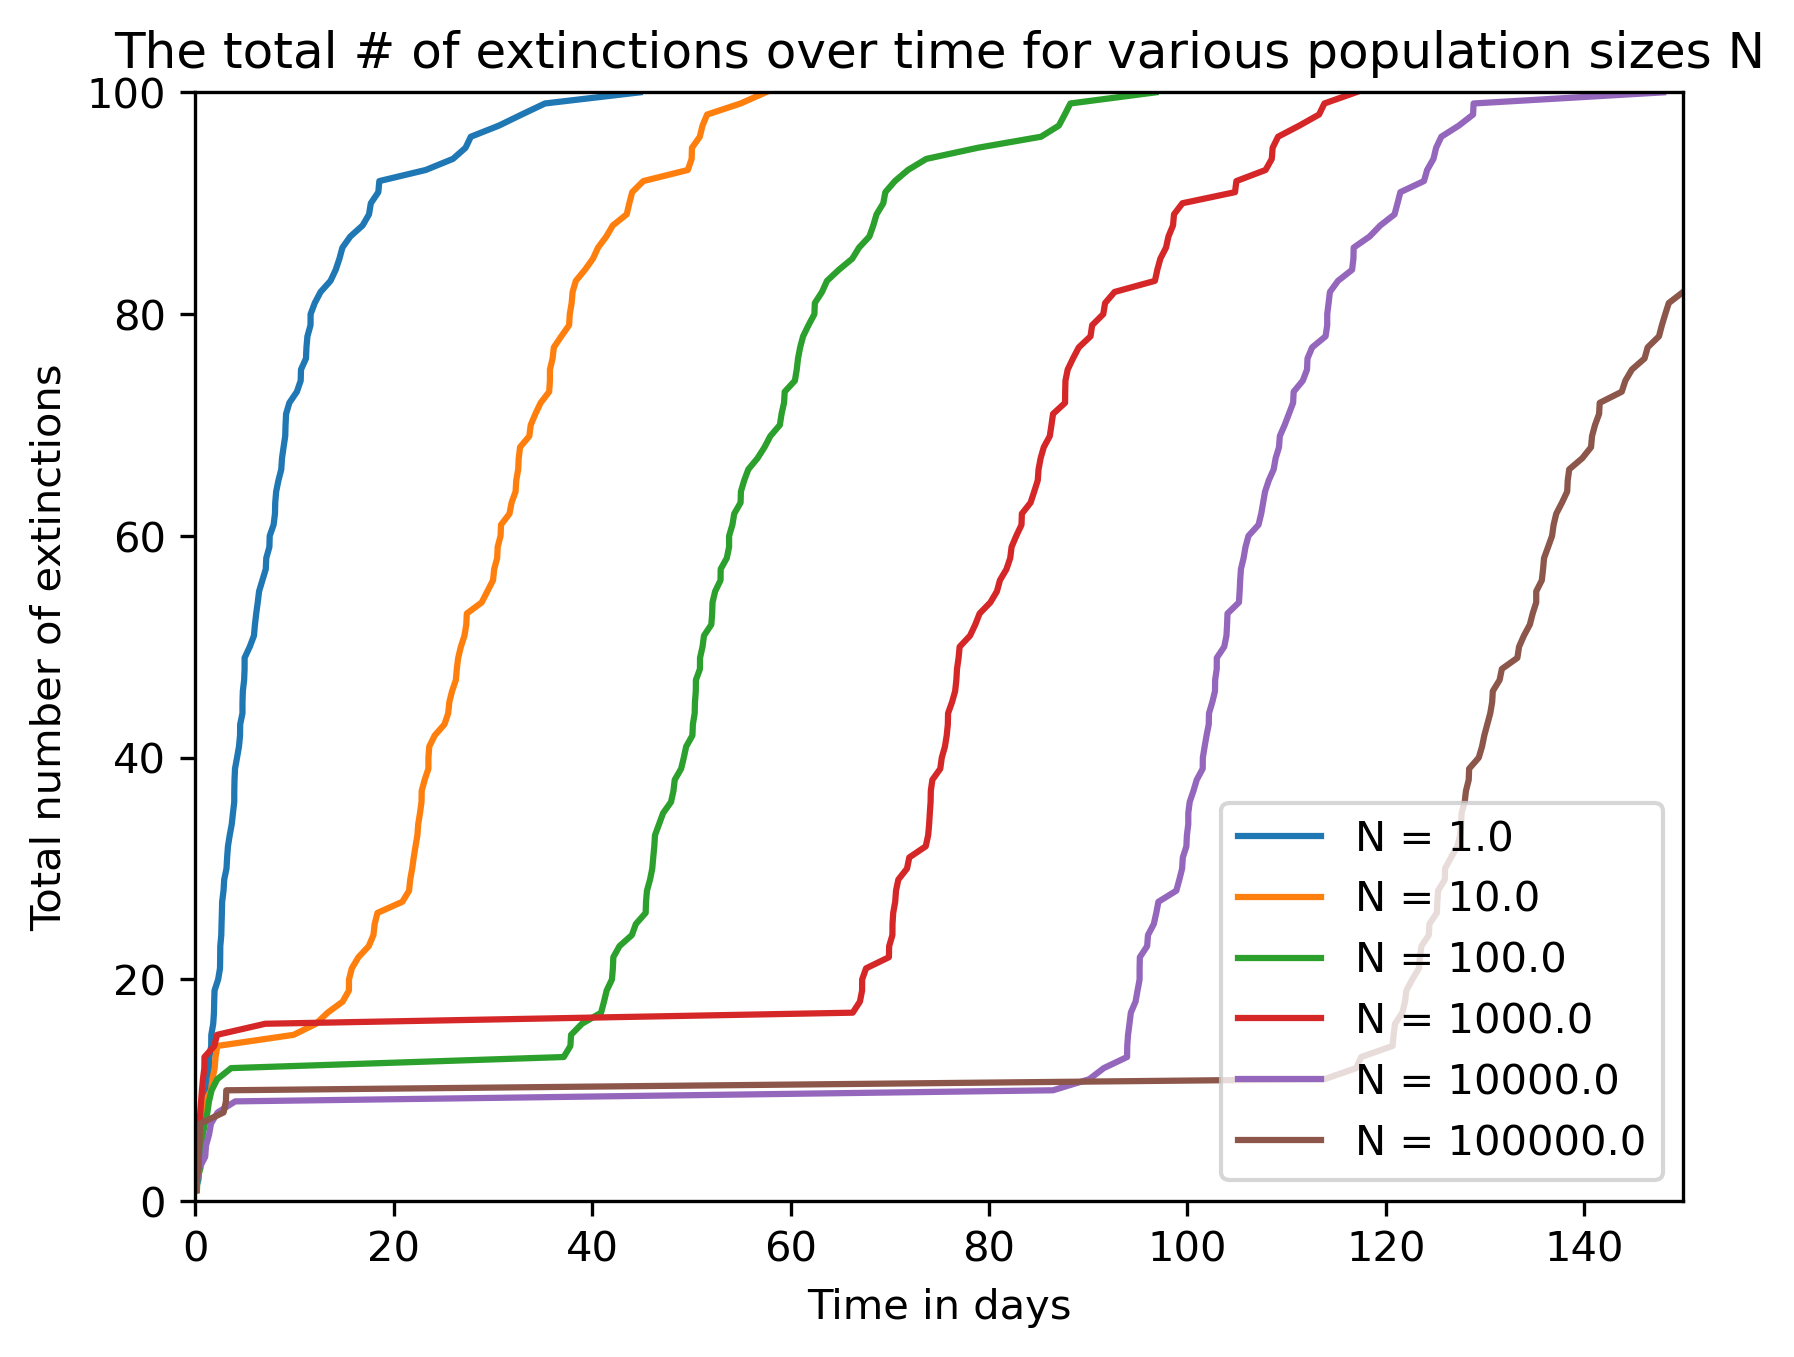

In [54]:
# TEST plot extinctions time series for different values of N
import time # TODO: remove

start = time.time() # TODO: remove
beta = 1
gamma = 0.1
mu = 0.02/365
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

N = [1e0, 1e1, 1e2, 1e3, 1e4, 1e5]

end_time = 150
no_runs = 100

for n in N:
    initial_values = get_initial_values_dict(n)
    extinction_times = get_number_of_extinctions_time_series(n, params, end_time, no_runs)

    lists = sorted(extinction_times.items()) # sorted by key, return a list of tuples

    x, y = zip(*lists) # unpack a list of pairs into two tuples
    
    y_cummulative = [y[0]]
    
    for i in range(len(y) - 1):
        y_cummulative.append(y_cummulative[i] + y[i+1])
    
    plt.plot(x, y_cummulative, label = rf'N = {n}')

end = time.time() # TODO: remove
print('The total time in seconds:') # TODO: remove
print(end - start) # TODO: remove

plt.axis([0, end_time, 0, no_runs])
plt.xlabel('Time in days')
plt.ylabel('Total number of extinctions')
plt.title('The total # of extinctions over time for various population sizes N')
plt.legend()
plt.show()

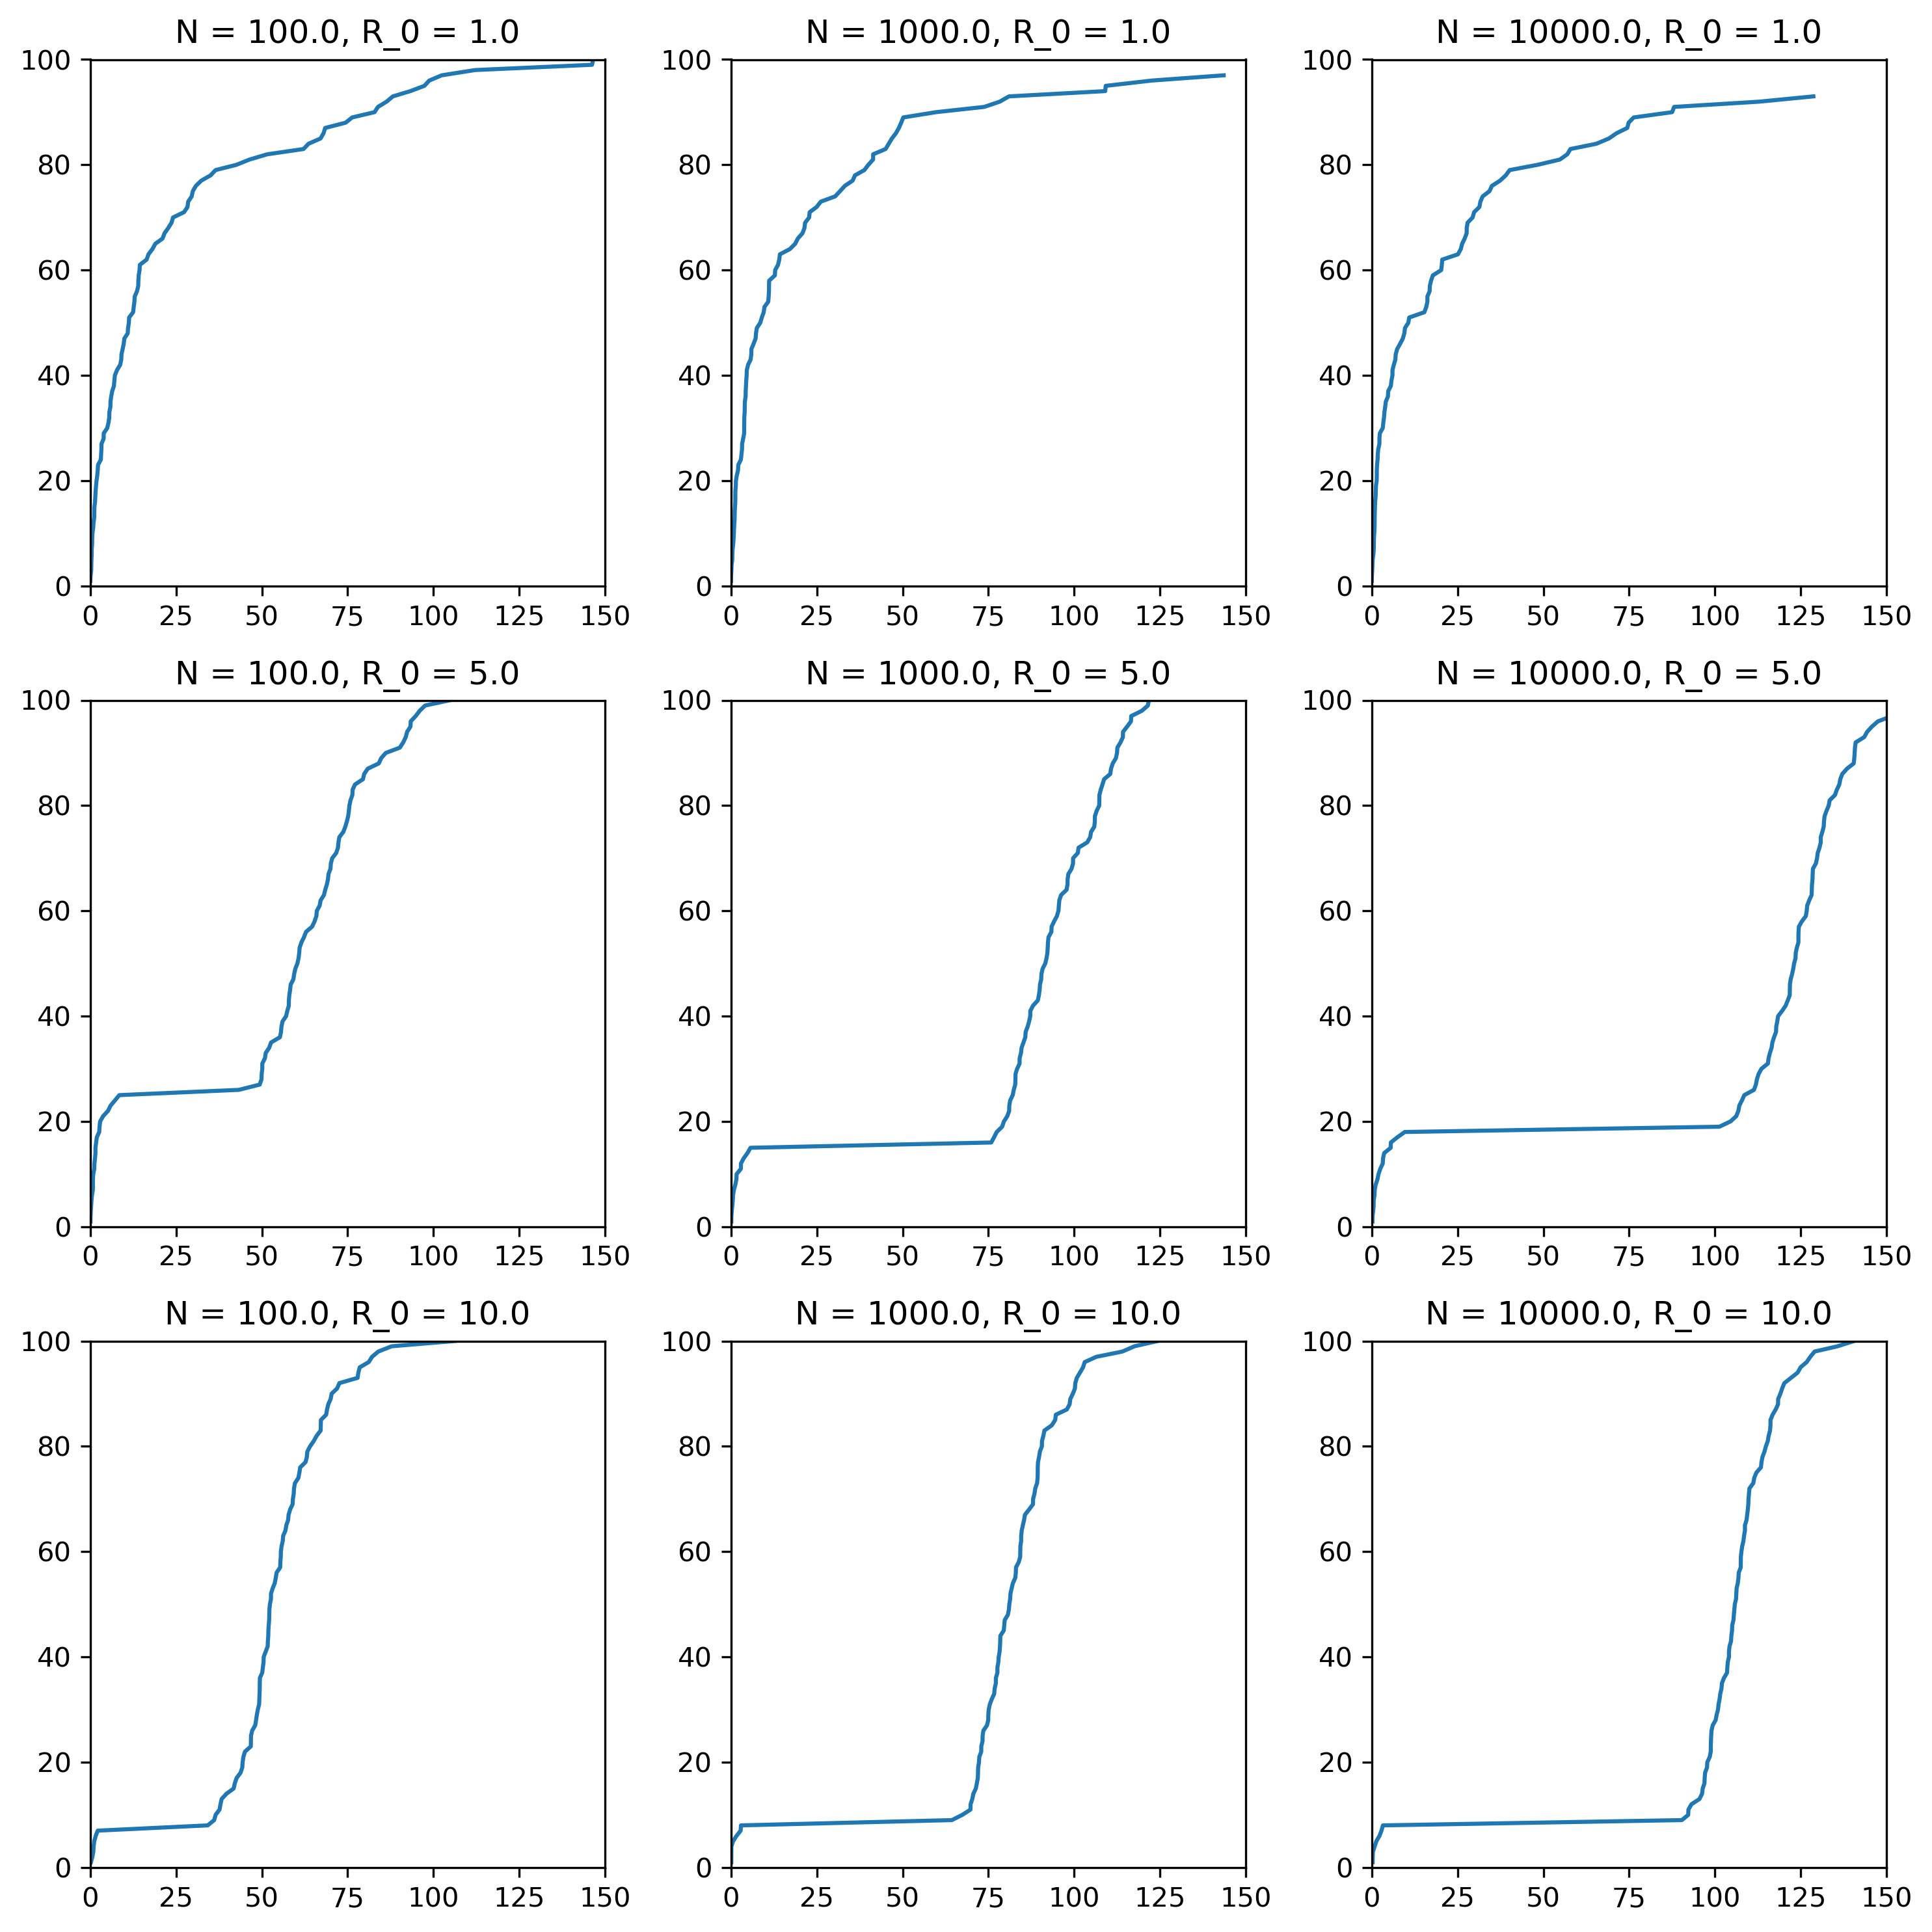

In [55]:
# TEST plot extinctions time series for different values of R_0 and N
betas = [0.1, 0.5, 1]
gamma = 0.1
mu = 0.02/365

N = [1e2, 1e3, 1e4]

end_time = 150
no_runs = 100

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))

for i, beta in enumerate(betas):
    params = {'beta': beta, 'gamma': gamma, 'mu': mu}
    for j, n in enumerate(N):
        initial_values = get_initial_values_dict(n)
        extinction_times = get_number_of_extinctions_time_series(n, params, end_time, no_runs)
    
        lists = sorted(extinction_times.items()) # sorted by key, return a list of tuples
    
        times, no_extinctions = zip(*lists) # unpack a list of pairs into two tuples
        
        no_extinctions_cummulative = [no_extinctions[0]]
        
        for k in range(len(no_extinctions) - 1):
            no_extinctions_cummulative.append(no_extinctions_cummulative[k] + no_extinctions[k+1])

        axes[i, j].plot(times, no_extinctions_cummulative)
        axes[i, j].set_title(f"N = {n}, R_0 = {beta/gamma}")
        axes[i, j].axis([0, end_time, 0, no_runs])

plt.tight_layout()
plt.show()

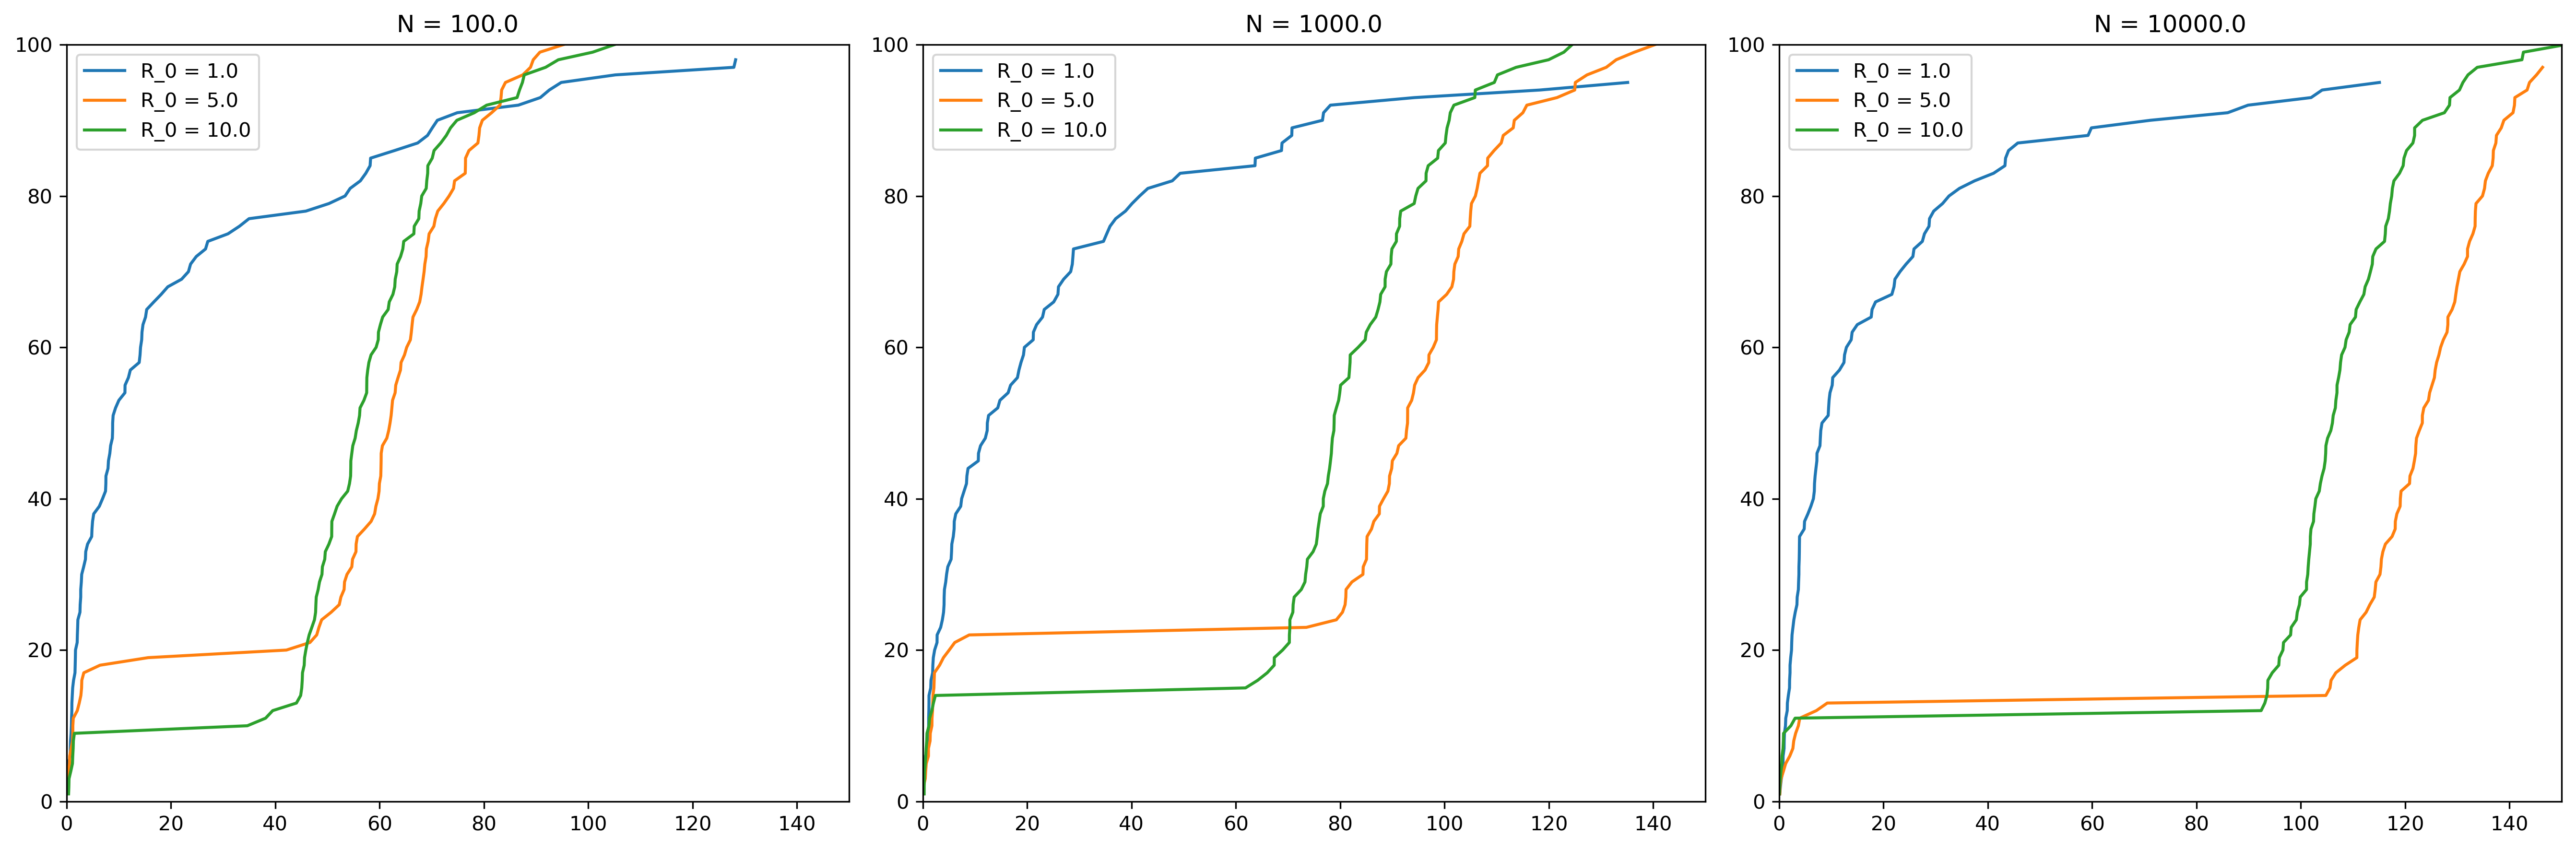

In [56]:
# TEST plot extinctions time series for different values of R_0 and N
betas = [0.1, 0.5, 1]
gamma = 0.1
mu = 0.02/365

N = [1e2, 1e3, 1e4]

end_time = 150
no_runs = 100

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, n in enumerate(N):
    initial_values = get_initial_values_dict(n)
    for beta in betas:
        params = {'beta': beta, 'gamma': gamma, 'mu': mu}
        extinction_times = get_number_of_extinctions_time_series(n, params, end_time, no_runs)
    
        lists = sorted(extinction_times.items()) # sorted by key, return a list of tuples
    
        times, no_extinctions = zip(*lists) # unpack a list of pairs into two tuples
        
        no_extinctions_cummulative = [no_extinctions[0]]
        
        for k in range(len(no_extinctions) - 1):
            no_extinctions_cummulative.append(no_extinctions_cummulative[k] + no_extinctions[k+1])

        axes[i].plot(times, no_extinctions_cummulative, label = f'R_0 = {beta/gamma}')
        axes[i].set_title(f'N = {n}')
        axes[i].axis([0, end_time, 0, no_runs])
        axes[i].legend()

plt.tight_layout()
plt.show()